In [28]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import sys
sys.path.append('/modules/rhel8/user-apps/fou-modules/fou-hi/toolbox/dev')
import toolbox
import datetime
# import matplotlib.dates as mdates
from matplotlib import dates as mdates


/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def latlon2xy(lat,lon,lat_arr,lon_arr,mask=None,maxoff=None,roundvals=True):
    import numpy as np
    from toolbox.utils.BFS import BFS
    a = abs( lat_arr-lat ) + abs( lon_arr-lon )
    ypos, xpos = np.unravel_index(a.argmin(), a.shape)
    if roundvals:
        xpos = int(np.round(xpos))
        ypos = int(np.round(ypos))
    if mask is not None:
        # NOTE: Mask should be 0 over land!!
        ypos_off, xpos_off = BFS(ypos, xpos, mask)
        if maxoff:
            if (np.sqrt((np.abs(xpos-xpos_off)**2)+(np.abs(ypos-ypos_off)**2)) > maxoff):
                print('offset too big')
                return None
            else:
                return xpos_off, ypos_off
        else:
            return xpos_off, ypos_off
    return xpos, ypos


In [3]:
# Define stuff:
# Input observations:
idir_obs          = '/lustre/storeB/users/nilsmk/stormrisk'
# Output data file:
ofile_nc          = os.path.join(idir_obs, 'anemoi_manuscript_obs_and_models_2010-2018_v2_5dec2025.nc')
# Output figures directory:
odir_figs         = '/lustre/storeB/users/nilsmk/anemoi-datasets/figs'
# Read observation dataset:
ifile_tseries_obs = os.path.join(idir_obs, 'aggregated_water_level_observations_with_pytide_prediction_dataset_extended_nor_stations_with_4_nora-surge_exps.nc')
if not os.path.exists(ofile_nc):
    ds_obs            = xr.open_dataset(ifile_tseries_obs)
    # Limit dataset to relevant time period:
    # ds_obs            = ds_obs.sel(time=slice('1980-01-01', '2023-01-01'))
    ds_obs            = ds_obs.sel(time=slice('2010-01-01', '2019-01-01'))
    # Select only hourly data:
    ds_obs            = ds_obs.sel(time=ds_obs['time'].dt.minute == 0)
    # Only select the following variables:
    ds_obs            = ds_obs[['stationid', 'latitude', 'longitude', 'observation', 'pytide_prediction', 'q_flag', 'nora3c']]
    # Remove some stations with known bad data:
    # Add stations to remove-list manually:
    remove_manual = ['DK_4203', 'DK_5103', 'DK_5104', 'NL_Aukfield platform', 'NL_F3 platform', 'NL_Maasmond stroommeetpaal', 'NL_Noordwijk meetpost', 'NL_Oosterschelde 11', ]
    for stationid in remove_manual:
        ds_obs = ds_obs.where(ds_obs['stationid'] != stationid, drop=True)
    # Now, if output file does not exist, create it:
# if not os.path.exists(ofile_nc):
    # Convert to dataframe:
    print('Converting observation dataset to dataframe and saving to netCDF file...')
    df_obs            = ds_obs.to_dataframe()

In [4]:
if not os.path.exists(ofile_nc):
    print('Calculating observation_surge and renaming nora3c to nora_surge...')
    # Create new column for observation_surge:
    df_obs['observation_surge'] = df_obs['observation'] - df_obs['pytide_prediction']
    # Rename nora3c to nora_surge:
    df_obs = df_obs.rename(columns={'nora3c': 'nora_surge'})

- First, read the nora3 corrected and put into new column
- Read in the anemoi runs, give good names
- Create a new column in the df with the anemoi run name
- Loop over the stations (or time?) and select the station data and put it into the correct index of the df. __Convert m to cm__
- Redo for more anemoi runs
- Store df to file
- Do statistics and plotting

In [5]:
if not os.path.exists(ofile_nc):
    print('Adding corrected NORA surge data to dataframe...')
    #
    nora_surge_corr = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2_corrected/{}/ocean_his.nc'
    files_corr = sorted(glob.glob(nora_surge_corr.format('201*')))
    #
    # Create a new column in the dataframe for the corrected nora surge:
    df_obs['nora_surge_corrected'] = np.nan
    #
    # Loop over files and read data, and put into the correct station and time in the dataframe. 
    # Ensure that the units are in cm (not m as in the netcdf files).
    # Calculate the x- and y-indices for each station once based on the first file. Ensure that the selected index contains valid data, else search nearby indices for valid data.
    ds_corr = xr.open_dataset(files_corr[0])
    maskr = np.where(np.isnan(ds_corr.zeta[0,:].values), 0, 1)
    # Precompute station grid indices based on the first file and the stations in df_obs
    station_indices = {}
    for sid,station_id in enumerate(ds_obs.stationid.values):
        print(f'Computing indices for station ID: {station_id}, no. {sid+1} of {len(ds_obs.stationid.values)}')
        lat_station = ds_obs.latitude.sel(station=np.where(ds_obs.stationid==station_id)[0][0]).values
        lon_station = ds_obs.longitude.sel(station=np.where(ds_obs.stationid==station_id)[0][0]).values
        x_index, y_index = latlon2xy(lat_station, lon_station, ds_corr['lat_rho'].values, ds_corr['lon_rho'].values, mask=maskr, roundvals=True)
        station_indices[station_id] = (sid, y_index, x_index)
        print(f'-->Station ID {station_id} assigned to grid indices (y: {y_index}, x: {x_index}). Original lat: {lat_station}, lon: {lon_station}, Grid lat: {ds_corr["lat_rho"][y_index, x_index].values}, lon: {ds_corr["lon_rho"][y_index, x_index].values}')
    ds_corr.close()

In [6]:
if os.path.exists(ofile_nc):
    print(f'Output file {ofile_nc} already exists. Will read data into dataframe from this file.')
    ds_obs = xr.open_dataset(ofile_nc)
    df_obs = ds_obs.to_dataframe()
    ds_obs.close()
else:
    for i, file in enumerate(files_corr):
        print(f'Reading file {i+1} of {len(files_corr)}: {file}')
        ds_corr = xr.open_dataset(file)
        zeta_data_all = ds_corr['zeta'].values * 100.0  # Convert from m to cm
        time_data = ds_corr['ocean_time'].values

        # Loop over stations and extract data
        for station_id, (sid, y_index, x_index) in list(station_indices.items()):
            # print(f'Processing station {sid+1} of {len(station_indices)}')
            
            # Extract data for specific station
            zeta_data = zeta_data_all[:, y_index, x_index]
            
            # Create a temporary dataframe
            df_temp = pd.DataFrame({
                'time': pd.to_datetime(time_data), 
                'nora_surge_corrected': zeta_data
            })
            df_temp.set_index('time', inplace=True)
            
            # --- THE FIX ---
            # 1. Identify rows in df_obs that match the current Station
            # 2. AND match the Time points present in the current file
            mask = (df_obs.index.get_level_values('station') == sid) & \
                (df_obs.index.get_level_values('time').isin(df_temp.index))
            
            # Only update the rows where the mask is True
            # We use .values on the right side to ignore index alignment issues during assignment
            df_obs.loc[mask, 'nora_surge_corrected'] = df_temp['nora_surge_corrected'].values
            
        del zeta_data_all
        ds_corr.close()
    # Save df_obs to a new netcdf file
    df_obs.to_xarray().to_netcdf(ofile_nc)

Output file /lustre/storeB/users/nilsmk/stormrisk/anemoi_manuscript_obs_and_models_2010-2018_v2_5dec2025.nc already exists. Will read data into dataframe from this file.


/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/xarray/backends/plugins.py:64: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'deprecated' from 'typing_extensions' (/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/typing_extensions.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [8]:
# # Rename all columns that start with "train5yr" to "train4yr"
# df_obs.columns = [col.replace('train5yr', 'train4yr') if col.startswith('train5yr') else col for col in df_obs.columns]
# # Store dataframe to netcdf file:
# df_obs.to_xarray().to_netcdf(ofile_nc)

In [7]:
sids_hovmoller = [97, 92, 93, 96, 39,43,42,23,7,57,56,55,88,86]

Processing station 97...
97: UK_Wick
Processing station 92...
92: UK_Aberdeen
Processing station 93...
93: UK_Whitby
Processing station 96...
96: UK_Lowestoft
Processing station 39...
39: NL_Platform Hoorn Q1-A
Processing station 43...
43: NL_Texel Noordzee
Processing station 42...
42: NL_Terschelling Noordzee
Processing station 23...
23: NL_Huibertgat
Processing station 7...
7: DE_Cuxhaven
Processing station 57...
57: DK_5203
Processing station 56...
56: DK_4303
Processing station 55...
55: DK_4201
Processing station 88...
88: SW_2111
Processing station 86...
86: SW_2130


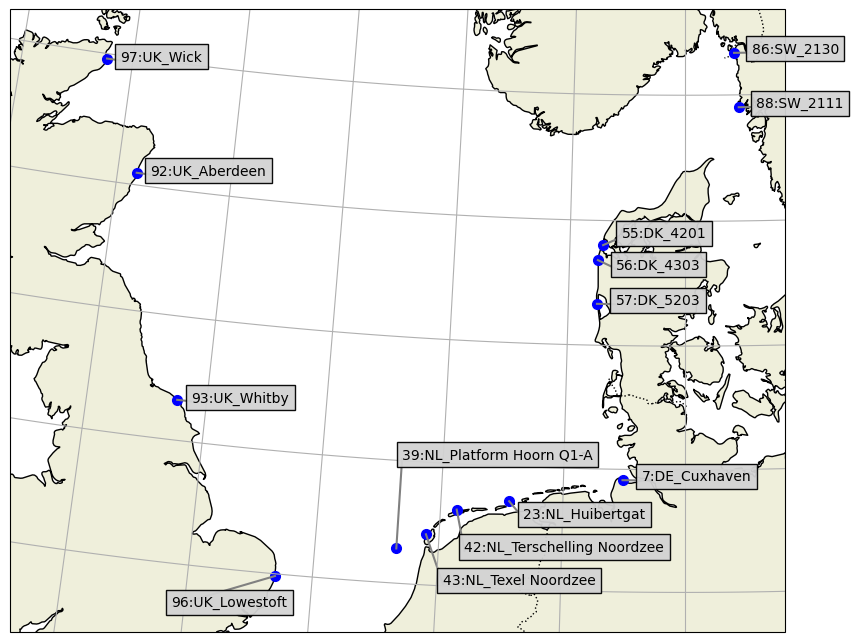

In [8]:
# Plot a map using cartopy with the stations in ofile_nc. Latitudes and longitudes are in df_obs.
# Add lat/lon gridlines
# Use stereographic projection centered over Norway.
#
vert_adjust = [0,     0,   0, -0.5,  1.1, -0.6, -0.5, -0.2,   0,   0, -0.1, 0.1,   0,   0]
hor_adjust =  [0.3, 0.3, 0.3,   -2,    0,  0.4,  0.2,  0.3, 0.4, 0.4,  0.4, 0.4, 0.4, 0.4]
if len(vert_adjust) != len(sids_hovmoller) or len(hor_adjust) != len(sids_hovmoller):
    print(f'Length of vert_adjust: {len(vert_adjust)}, length of hor_adjust: {len(hor_adjust)}, length of sids_hovmoller: {len(sids_hovmoller)}')
    print('Warning: vert_adjust length does not match number of stations to plot! No vertical adjustment will be applied.')
    vert_adjust = [0] * len(sids_hovmoller)
    hor_adjust = [0] * len(sids_hovmoller)
# 
# Set extent:
latmin = 52
latmax = 59
lonmin = -3.5
lonmax = 12
# Skip some stations:
skip_stations = ['NO_', 'WL_']
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,10))
# ax = plt.axes(projection=ccrs.Stereographic(central_longitude=10, central_latitude=65))
# Try with LambertConformal:
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=10, central_latitude=65))
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
# Mask stations outside of the map extent:

# Plot station locations
for i, sid in enumerate(sids_hovmoller):
# for sid in df_obs.index.get_level_values('station').unique():
    print(f'Processing station {sid}...')
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    if station_id[:3] in skip_stations:
        print(f'skip {station_id}')
    else:
        lat_station = df_obs.xs(sid, level='station').latitude.values[0]
        lon_station = df_obs.xs(sid, level='station').longitude.values[0]
        if lat_station > latmin and lat_station < latmax:
            if lon_station > lonmin and lon_station < lonmax:
                ax.plot(lon_station, lat_station, marker='o', color='blue', markersize=7, transform=ccrs.PlateCarree())
                # ax.text(lon_station+0.02, lat_station+0.02, f'{sid}:{station_id}', transform=ccrs.PlateCarree(), size=8)
                ax.text(lon_station+hor_adjust[i], lat_station+vert_adjust[i], f'{sid}:{station_id}', transform=ccrs.PlateCarree(), size=10, bbox=dict(facecolor='lightgrey', alpha=0.95))
                print(f'{sid}: {station_id}')
                # Plot a line from the station point to the text label
                ax.plot([lon_station, lon_station+hor_adjust[i]], 
                        [lat_station, lat_station+vert_adjust[i]], 
                        color='gray', linewidth=1.5, transform=ccrs.PlateCarree())
# Add lat/lon gridlines
ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
# gl = ax.gridlines(draw_labels=True)
gl = ax.gridlines(draw_labels=False)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = False
gl.bottom_labels = False
# plt.title('Station locations from observation dataset')
plt.show()


In [11]:
df_obs.columns

Index(['stationid', 'latitude', 'longitude', 'observation',
       'pytide_prediction', 'q_flag', 'nora_surge', 'observation_surge',
       'nora_surge_corrected', 'train16yr_uncorr_10d_100k',
       'train16yr_corr_10d_100k', 'train16yr_uncorr_1year_100k',
       'train16yr_corr_1year_100k', 'train4yr_uncorr_10d_25k',
       'train4yr_uncorr_1year_25k', 'train4yr_uncorr_10d_50k',
       'train4yr_uncorr_1year_50k', 'train4yr_uncorr_10d_100k',
       'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k',
       'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k',
       'train16yr_uncorr_xaver_100k', 'train16yr_corr_xaver_100k',
       'train4yr_uncorr_xaver_100k', 'train16yr_uncorr_2010-2018_100k',
       'train4yr_uncorr_2010-2018_100k'],
      dtype='object')

In [12]:
df_obs.xs(97, level='station')['nora_surge']

time
2010-01-01 00:00:00   -16.858007
2010-01-01 01:00:00   -14.858983
2010-01-01 02:00:00   -14.255450
2010-01-01 03:00:00   -12.662156
2010-01-01 04:00:00   -14.018313
                         ...    
2019-01-01 19:00:00   -14.649345
2019-01-01 20:00:00   -15.854261
2019-01-01 21:00:00   -19.501032
2019-01-01 22:00:00   -23.495564
2019-01-01 23:00:00   -26.658443
Name: nora_surge, Length: 78912, dtype: float32

## Create Hovmoeller diagram

In [9]:
# Create a function using the haversine formula to calculate distance between two lat/lon points
def haversine(lat1, lon1, lat2, lon2):
    import numpy as np
    R = 6371.0  # Earth radius in kilometers
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c
    return distance

In [10]:
# sids_hovmoller = [97, 92, 93, 96, 39,43,42,23,7,57,56,55,88,86]
lats_arr = np.zeros(len(sids_hovmoller))
lons_arr = np.zeros(len(sids_hovmoller))
for ii, ss in enumerate(sids_hovmoller):
    station_id = df_obs.xs(ss, level='station').stationid.values[0]
    print(station_id)
    obsvals = df_obs.xs(ss, level='station')['observation_surge'].values
    noravals = df_obs.xs(ss, level='station')['nora_surge'].values
    flo4vals = df_obs.xs(ss, level='station')['train4yr_uncorr_2010-2018_100k'].values
    flo16vals = df_obs.xs(ss, level='station')['train16yr_uncorr_2010-2018_100k'].values
    #
    lat_station = df_obs.xs(ss, level='station').latitude.values[0]
    lon_station = df_obs.xs(ss, level='station').longitude.values[0]
    lats_arr[ii] = lat_station
    lons_arr[ii] = lon_station
    #
    if ii == 0:
        obsarr = np.zeros([len(sids_hovmoller),len(obsvals)])
        noraarr = np.zeros([len(sids_hovmoller),len(obsvals)])
        flo4arr = np.zeros([len(sids_hovmoller),len(obsvals)])
        flo16arr = np.zeros([len(sids_hovmoller),len(obsvals)])
        timearr = df_obs.xs(ss, level='station').observation.index
    obsarr[ii,:] = obsvals
    noraarr[ii,:] = noravals
    flo4arr[ii,:] = flo4vals
    flo16arr[ii,:] = flo16vals
dist_arr = np.zeros(len(sids_hovmoller))
for i in range(1,len(sids_hovmoller)):
    dist_arr[i] = dist_arr[i-1] + haversine(lats_arr[i-1], lons_arr[i-1], lats_arr[i], lons_arr[i])

UK_Wick
UK_Aberdeen
UK_Whitby
UK_Lowestoft
NL_Platform Hoorn Q1-A
NL_Texel Noordzee
NL_Terschelling Noordzee
NL_Huibertgat
DE_Cuxhaven
DK_5203
DK_4303
DK_4201
SW_2111
SW_2130


In [11]:
# Interpolate noraarr along the distance axis onto a uniform grid
dist_uniform = np.linspace(dist_arr.min(), dist_arr.max(), 200)
obsarr_interp = np.full((len(timearr), len(dist_uniform)), np.nan)
noraarr_interp = np.full((len(timearr), len(dist_uniform)), np.nan)
flo4arr_interp = np.full((len(timearr), len(dist_uniform)), np.nan)
flo16arr_interp = np.full((len(timearr), len(dist_uniform)), np.nan)

for ti in range(len(timearr)):
    yvals = noraarr[:, ti]
    valid = np.isfinite(yvals)
    if valid.sum() >= 2:
        noraarr_interp[ti, :] = np.interp(dist_uniform, dist_arr[valid], yvals[valid])
    yvals = obsarr[:, ti]
    valid = np.isfinite(yvals)
    if valid.sum() >= 2:
        obsarr_interp[ti, :] = np.interp(dist_uniform, dist_arr[valid], yvals[valid])
    yvals = flo4arr[:, ti]
    valid = np.isfinite(yvals)
    if valid.sum() >= 2:
        flo4arr_interp[ti, :] = np.interp(dist_uniform, dist_arr[valid], yvals[valid])
    yvals = flo16arr[:, ti]
    valid = np.isfinite(yvals)
    if valid.sum() >= 2:
        flo16arr_interp[ti, :] = np.interp(dist_uniform, dist_arr[valid], yvals[valid])

# noraarr_interp now has the same time dimension as noraarr (timearr)
# and is interpolated along a uniformly spaced distance axis (dist_uniform)

In [12]:
from scipy.interpolate import griddata

# Interpolate using bilinear interpolation (method='linear' in griddata)
dist_uniform = np.linspace(dist_arr.min(), dist_arr.max(), 200)
obsarr_interp_bilinear = np.full((len(timearr), len(dist_uniform)), np.nan)
noraarr_interp_bilinear = np.full((len(timearr), len(dist_uniform)), np.nan)
flo4arr_interp_bilinear = np.full((len(timearr), len(dist_uniform)), np.nan)
flo16arr_interp_bilinear = np.full((len(timearr), len(dist_uniform)), np.nan)

for ti in range(len(timearr)):
    # Observation surge
    yvals = obsarr[:, ti]
    valid = np.isfinite(yvals)
    if valid.sum() >= 2:
        obsarr_interp_bilinear[ti, :] = griddata(dist_arr[valid], yvals[valid], dist_uniform, method='linear')
    
    # NORA surge
    yvals = noraarr[:, ti]
    valid = np.isfinite(yvals)
    if valid.sum() >= 2:
        noraarr_interp_bilinear[ti, :] = griddata(dist_arr[valid], yvals[valid], dist_uniform, method='linear')
    
    # Flo 4yr
    yvals = flo4arr[:, ti]
    valid = np.isfinite(yvals)
    if valid.sum() >= 2:
        flo4arr_interp_bilinear[ti, :] = griddata(dist_arr[valid], yvals[valid], dist_uniform, method='linear')
    
    # Flo 16yr
    yvals = flo16arr[:, ti]
    valid = np.isfinite(yvals)
    if valid.sum() >= 2:
        flo16arr_interp_bilinear[ti, :] = griddata(dist_arr[valid], yvals[valid], dist_uniform, method='linear')

In [17]:
colormap = 'plasma'
# # Xaver:
# # Dec 2017:
# minval = -100
# maxval = 200


# Xaver:
d1 = datetime.datetime(2013,12,4)
d2 = datetime.datetime(2013,12,8)
minval = -150
maxval = 350
selected_levels = [-150, -100, -50, 0, 50, 100, 150, 200, 250, 300, 350]

# # Other events:
# d1 = datetime.datetime(2010,10,20)
# d2 = datetime.datetime(2010,10,27)
# minval = -100
# maxval = 100
# selected_levels = [-50, 0, 50, 100]

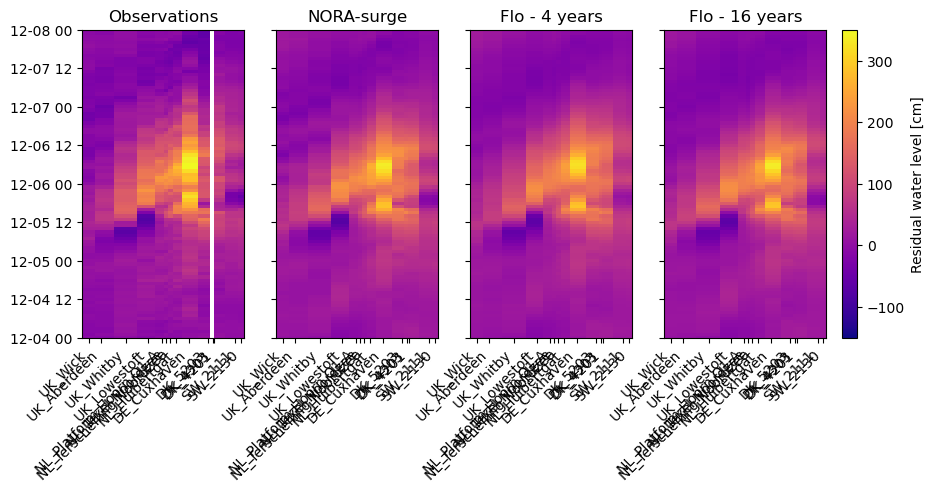

In [18]:
fig, ax = plt.subplots(1, 4, figsize=(10, 4), sharex=True, sharey=True)


im1 = ax[0].pcolormesh(dist_arr, timearr, obsarr.T, vmin=minval, vmax=maxval, cmap=colormap)
ax[0].set_title('Observations')
im2 = ax[1].pcolormesh(dist_arr, timearr, noraarr.T, vmin=minval, vmax=maxval, cmap=colormap)
ax[1].set_title('NORA-surge')
im3 = ax[2].pcolormesh(dist_arr, timearr, flo4arr.T, vmin=minval, vmax=maxval, cmap=colormap)
ax[2].set_title('Flo - 4 years')
im4 = ax[3].pcolormesh(dist_arr, timearr, flo16arr.T, vmin=minval, vmax=maxval, cmap=colormap)
ax[3].set_title('Flo - 16 years')
# Limit date to display to december 2013:
import datetime
ax[0].set_ylim(d1, d2)
# Add station_id as names to x-axis:
for i in range(len(ax)):
    ax[i].set_xticks(dist_arr)
    ax[i].set_xticklabels([df_obs.xs(ss, level='station').stationid.values[0] for ss in sids_hovmoller], rotation=45, ha='right')
#
# fig.colorbar(im1, ax=ax, orientation='horizontal', fraction=0.1, pad=0.2, label='Residual water level [cm]')
# Move the colorbar to the right of the subplots
fig.colorbar(im1, ax=ax, orientation='vertical', fraction=0.02, pad=0.02, label='Residual water level [cm]')
plt.show()

In [19]:
# fig, ax = plt.subplots(1, 4, figsize=(10, 4), sharex=True, sharey=True)

# im1 = ax[0].pcolormesh(dist_uniform, timearr, obsarr_interp, vmin=minval, vmax=maxval, cmap=colormap)
# ax[0].set_title('Observations (interp)')
# im2 = ax[1].pcolormesh(dist_uniform, timearr, noraarr_interp, vmin=minval, vmax=maxval, cmap=colormap)
# ax[1].set_title('NORA-surge (interp)')
# im3 = ax[2].pcolormesh(dist_uniform, timearr, flo4arr_interp, vmin=minval, vmax=maxval, cmap=colormap)
# ax[2].set_title('Flo - 4 years (interp)')
# im4 = ax[3].pcolormesh(dist_uniform, timearr, flo16arr_interp, vmin=minval, vmax=maxval, cmap=colormap)
# ax[3].set_title('Flo - 16 years (interp)')

# ax[0].set_ylim(d1, d2)

# for i in range(len(ax)):
#     ax[i].set_xticks(dist_arr)
#     ax[i].set_xticklabels([df_obs.xs(ss, level='station').stationid.values[0] for ss in sids_hovmoller],
#                           rotation=45, ha='right')

# # fig.colorbar(im1, ax=ax, orientation='horizontal', fraction=0.1, pad=0.2, label='Residual water level [cm]')
# # Move the colorbar to the right of the subplots
# fig.colorbar(im1, ax=ax, orientation='vertical', fraction=0.02, pad=0.02, label='Residual water level [cm]')
# plt.show()

Maximum value in NORA-surge interp bilinear cut: 333 cm at time 2013-12-06 06:00:00 and distance 1229 km
[   0.         1881.37436296]
DatetimeIndex(['2013-12-05 14:28:54.612339600', '2013-12-06 14:14:11.628837600'], dtype='datetime64[ns]', freq=None)


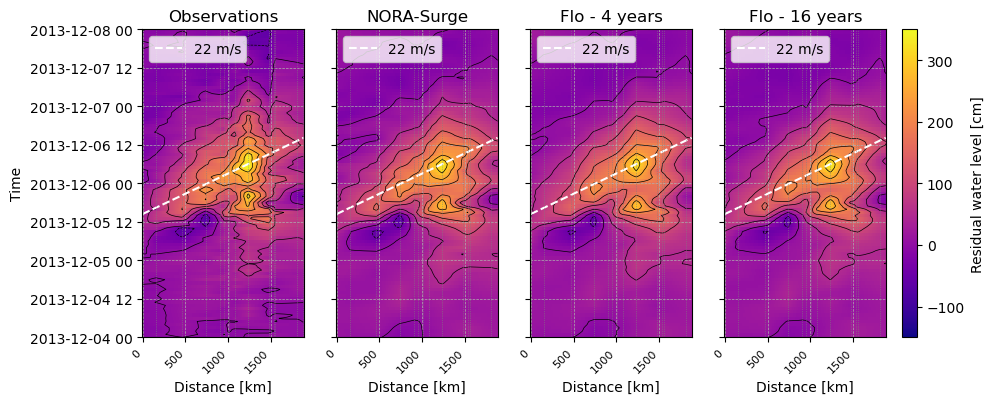

In [19]:
# Kelvin wave speed:
cw = 22  # m/s
x_idx_max = np.zeros(len(sids_hovmoller), dtype=int)
y_idx_max = np.zeros(len(sids_hovmoller), dtype=int)
# Cut out the part of the _interp_bilinear arrays within the time range d1 to d2:
obsarr_interp_bilinear_cut = obsarr_interp_bilinear[(timearr >= d1) & (timearr <= d2), :]
noraarr_interp_bilinear_cut = noraarr_interp_bilinear[(timearr >= d1) & (timearr <= d2), :]
flo4arr_interp_bilinear_cut = flo4arr_interp_bilinear[(timearr >= d1) & (timearr <= d2), :]
flo16arr_interp_bilinear_cut = flo16arr_interp_bilinear[(timearr >= d1) & (timearr <= d2), :]
timearr_cut = timearr[(timearr >= d1) & (timearr <= d2)]
# Do same as above but for bilinear interpolation
fig, ax = plt.subplots(1, 4, figsize=(10, 4), sharex=True, sharey=True) 
im1 = ax[0].pcolormesh(dist_uniform, timearr_cut, obsarr_interp_bilinear_cut, vmin=minval, vmax=maxval, cmap=colormap)
ax[0].set_title('Observations')
ax[0].contour(dist_uniform, timearr_cut, obsarr_interp_bilinear_cut, levels=selected_levels, colors='k', linewidths=0.5)
# Find the index of the maximum value in noraarr_interp_bilinear_cut:
y_idx_max[0], x_idx_max[0] = np.unravel_index(np.nanargmax(noraarr_interp_bilinear_cut), noraarr_interp_bilinear_cut.shape)
print(f'Maximum value in NORA-surge interp bilinear cut: {noraarr_interp_bilinear_cut[y_idx_max[0], x_idx_max[0]]:.0f} cm at time {timearr_cut[y_idx_max[0]]} and distance {dist_uniform[x_idx_max[0]]:.0f} km')
# Add a line with slope 3 m/s going through the maximum point:
slope_km_per_hr = cw * 3.6  # 3 m/s in km/hr
x_vals = np.array([0, dist_uniform.max()])
print(x_vals)
# Create a timedelta explicitly specifying the unit (e.g., 'h' for hours)
y_vals = timearr_cut[y_idx_max[0]] + pd.to_timedelta((x_vals - dist_uniform[x_idx_max[0]]) / slope_km_per_hr, unit='h')
print(y_vals)
ax[0].plot(x_vals, y_vals, color='white', linestyle='--', linewidth=1.5, label=f'{cw} m/s')
ax[0].legend()
#
im2 = ax[1].pcolormesh(dist_uniform, timearr_cut, noraarr_interp_bilinear_cut, vmin=minval, vmax=maxval, cmap=colormap)
ax[1].set_title('NORA-Surge')
ax[1].contour(dist_uniform, timearr_cut, noraarr_interp_bilinear_cut, levels=selected_levels, colors='k', linewidths=0.5)
ax[1].plot(x_vals, y_vals, color='white', linestyle='--', linewidth=1.5, label=f'{cw} m/s')
ax[1].legend()
#
im3 = ax[2].pcolormesh(dist_uniform, timearr_cut, flo4arr_interp_bilinear_cut, vmin=minval, vmax=maxval, cmap=colormap)
ax[2].set_title('Flo - 4 years')
ax[2].contour(dist_uniform, timearr_cut, flo4arr_interp_bilinear_cut, levels=selected_levels, colors='k', linewidths=0.5)
ax[2].plot(x_vals, y_vals, color='white', linestyle='--', linewidth=1.5, label=f'{cw} m/s')
ax[2].legend()
#
im4 = ax[3].pcolormesh(dist_uniform, timearr_cut, flo16arr_interp_bilinear_cut, vmin=minval, vmax=maxval, cmap=colormap)
ax[3].set_title('Flo - 16 years')
ax[3].contour(dist_uniform, timearr_cut, flo16arr_interp_bilinear_cut, levels=selected_levels, colors='k', linewidths=0.5)
ax[3].plot(x_vals, y_vals, color='white', linestyle='--', linewidth=1.5, label=f'{cw} m/s')
ax[3].legend()
#
ax[0].set_ylim(d1, d2)
for i in range(len(ax)):
    # ax[i].set_xticks(dist_arr)
    # ax[i].set_xticklabels([df_obs.xs(ss, level='station').stationid.values[0] for ss in sids_hovmoller],
    #                       rotation=45, ha='right', size=6)
    # ax[i].set_xticklabels([ss for ss in sids_hovmoller], size=6)
    # Use dist_arr as x-ticks and labels:
    # ax[i].set_xticklabels([f'{ss:.0f}' for ss in dist_arr], rotation=90, size=6)
    # Add x ticks and labels for every 500 km:
    xtick_locs = np.arange(0, dist_uniform.max()+1, 500)
    ax[i].set_xticks(xtick_locs)
    ax[i].set_xticklabels([f'{loc:.0f}' for loc in xtick_locs], rotation=45, ha='right', size=8)
    # Add gridlines to each subplot
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.5)
    ax[i].set_xlabel('Distance [km]')
    # Add vertical lines for station locations
    for dist in dist_arr:
        ax[i].axvline(x=dist, color='gray', linestyle=':', linewidth=0.5)
        # Add text labels for station IDs inside the plot, rotated 90 degrees:
        # ax[i].text(dist+5, d1 + (d2 - d1)*0.05, f'{df_obs.xs(sids_hovmoller[np.argmin(np.abs(dist_arr - dist))], level="station").stationid.values[0]}', rotation=90, size=6, color='black', backgroundcolor='lightgrey')
# Plot the y-axis tick labels using the format 'YYYY-MM-DD HH':
ax[0].yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H'))
ax[0].set_ylabel('Time')

# fig.colorbar(im1, ax=ax, orientation='horizontal', fraction=0.1, pad=0.2, label='Residual water level [cm]')
# Move the colorbar to the right of the subplots
fig.colorbar(im1, ax=ax, orientation='vertical', fraction=0.02, pad=0.02, label='Residual water level [cm]')
plt.show()

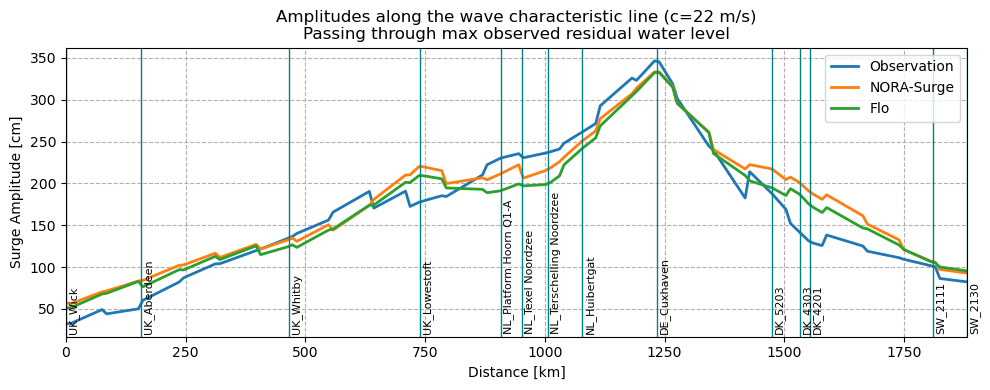

In [20]:
# Extract values along the characteristic line
# Line definition parameters (from previous cell):
# Point: (dist_uniform[x_idx_max[0]], timearr_cut[y_idx_max[0]])
# Slope: slope_km_per_hr = cw * 3.6 (km/h)

# 1. Calculate the target time for every point in dist_uniform
#    y - y0 = m * (x - x0)  -> t_target = t0 + (x - x0)/speed
t0 = timearr_cut[y_idx_max[0]]
x0 = dist_uniform[x_idx_max[0]]
times_on_line = t0 + pd.to_timedelta((dist_uniform - x0) / slope_km_per_hr, unit='h')

# 2. Find the nearest index in timearr_cut for each target time
#    We will use nearest neighbor method.
#    Since arrays are small (time ~ 100, dist ~ 200), we can just compute differences.
time_int = timearr_cut.astype(np.int64)
target_int = times_on_line.astype(np.int64)

# Array of shape (len(timearr_cut), len(dist_uniform))
search_matrix = np.abs(time_int.values[:, None] - target_int.values)
nearest_time_indices = search_matrix.argmin(axis=0)

# 3. Create a mask for times that are actually within the bounds of timearr_cut
#    Check if the Time difference is within 30 minutes (since data is hourly, if diff > 30min implies we are extrapolating outside range)
one_hour_ns = 3600 * 1e9
time_diffs_ns = search_matrix.min(axis=0)
valid_mask = time_diffs_ns <= (0.55 * one_hour_ns)  # Allow slight wiggle room > 0.5h for float inaccuracies

# 4. Extract data
#    Grid x-indices are just 0, 1, 2... len(dist)
dist_indices = np.arange(len(dist_uniform))

arrays_to_plot = {
    'Observation': obsarr_interp_bilinear_cut,
    'NORA-Surge': noraarr_interp_bilinear_cut,
    'Flo': flo16arr_interp_bilinear_cut,
    # 'Flo (4yr)': flo4arr_interp_bilinear_cut,
    # 'Flo (16yr)': flo16arr_interp_bilinear_cut
}

plt.figure(figsize=(10, 4))

for name, data_arr in arrays_to_plot.items():
    # Extract values: data_arr[time_idx, dist_idx]
    # Initialize with NaNs
    line_values = np.full(len(dist_uniform), np.nan)
    
    # Fill valid points
    line_values[valid_mask] = data_arr[nearest_time_indices[valid_mask], dist_indices[valid_mask]]
    
    plt.plot(dist_uniform, line_values, label=name, linewidth=2)

plt.title(f'Amplitudes along the wave characteristic line (c={cw} m/s)\nPassing through max observed residual water level')
plt.xlabel('Distance [km]')
plt.ylabel('Surge Amplitude [cm]')
plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.xlim(dist_uniform.min(), dist_uniform.max())

# Helper to position station labels:
ylim = plt.gca().get_ylim()
y_txt = ylim[0] + (ylim[1]-ylim[0])*0.02

# Add vertical lines for station locations
for dist in dist_arr:
    plt.axvline(x=dist, color='teal', linestyle='-', linewidth=1.)
    # Add text labels for station IDs inside the plot, rotated 90 degrees:
    plt.text(dist+5, y_txt, f'{df_obs.xs(sids_hovmoller[np.argmin(np.abs(dist_arr - dist))], level="station").stationid.values[0]}', rotation=90, size=8, color='black')

plt.tight_layout()
plt.show()

In [26]:
dist_arr

array([   0.        ,  156.04863446,  465.02276939,  738.4764081 ,
        907.79509427,  952.41959325, 1006.00329344, 1077.9519843 ,
       1233.99441397, 1474.05799538, 1532.52501487, 1553.67037458,
       1809.6732956 , 1881.37436296])

In [ ]:
# plt.plot(timearr,flo16arr[0,:])
plt.plot(timearr,flo16arr[1,:])
plt.plot(timearr,flo16arr[2,:])

# plt.plot(timearr,flo16arr[-3,:])
# plt.plot(timearr,flo16arr[-2,:])
# plt.plot(timearr,flo16arr[-1,:])

plt.xlim(datetime.datetime(2010,10,20), datetime.datetime(2010,11,1))
plt.ylim(-50,110)

NameError: name 'plt' is not defined

In [ ]:
fft_result

array([nan +0.j, nan+nanj, nan+nanj, ..., nan+nanj, nan+nanj, nan+nanj])

/tmp/ipykernel_3904112/825548838.py:12: RuntimeWarning: divide by zero encountered in divide
  plt.plot(1/frequencies/3600, np.abs(fft_result))


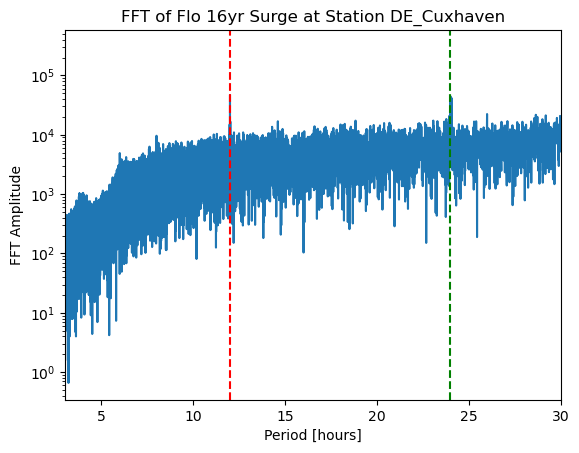

In [ ]:
# Using numpy.fft, do FFT of flo16arr[-3,:] with timearr as time axis:
# 1. Calculate the sampling frequency based on timearr
import numpy as np
time_diffs = np.diff(timearr)  # Time differences between consecutive samples
sampling_interval = np.median(time_diffs).astype('timedelta64[s]').item().total_seconds()  # Median sampling interval in seconds
sampling_frequency = 1 / sampling_interval  # Sampling frequency in Hz
# Now perform FFT, keep in mind that the input array includes nan values, so we need to handle that:
valid_indices = ~np.isnan(flo16arr[-3,:])
fft_result = np.fft.fft(flo16arr[-3,valid_indices])
frequencies = np.fft.fftfreq(len(flo16arr[-3,valid_indices]), d=sampling_interval)
# Plot the FFT result based on periods:
plt.plot(1/frequencies/3600, np.abs(fft_result))
# Use logarithmic scale for y-axis:
plt.yscale('log')
plt.xlim(3, 30)  # Limit x-axis to periods up to one week (in hours)
# Add vertical line at 12 hours and 24 hours:
plt.axvline(x=12, color='red', linestyle='--')
plt.axvline(x=24, color='green', linestyle='--')
plt.xlabel('Period [hours]')
plt.ylabel('FFT Amplitude')
plt.title('FFT of Flo 16yr Surge at Station {}'.format(df_obs.xs(sids_hovmoller[-3], level='station').stationid.values[0]))
plt.show()

## Add more data

In [ ]:
# Now add the anemoi experiments:
idir_anemoi = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/{}/inference'
# Exps: (foldername, shortname, nc_filepattern)
exps_anemoi = [
            #    ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_10d_100k', '????-??-??_240h_step100000.nc'), 
            #    ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_10d_100k', '????-??-??_240h_step100000.nc'),
            #    ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_1year_100k', '????-??-??_1year_step100000.nc'), 
            #    ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_1year_100k', '????-??-??_1year_step100000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_10d_25k', '????-??-??_240h_step025000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_1year_25k', '????-??-??_1year_step025000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_10d_50k', '????-??-??_240h_step050000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_1year_50k', '????-??-??_1year_step050000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_10d_100k', '????-??-??_240h_step100000.nc'),
            #    # ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_1year_100k', '????-??-??_1year_step100000.nc'), # not added yet, not run inference yet.
               # ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_didrik_100k', 'didrik_2010-01-09_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_didrik_100k', 'didrik_2010-01-09_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_elsa_100k', 'elsa_2010-02-05_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_elsa_100k', 'elsa_2010-02-05_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_xaver_100k', 'xaver_2013-12-01_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_xaver_100k', 'xaver_2013-12-01_240h_step100000.nc'),
               # ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_xaver_100k', 'xaver_2013-12-01_240h_step100000.nc'),
               ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_2010-2018_100k', 'long_????-??-??_78840h_step100000.nc'),
               ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_2010-2018_100k', 'long_????-??-??_78840h_step100000.nc'),
               ]
            # Do inference for 10 days for 5yr train based on 100k, and also 25k
            # Do inference for 1 year for all runs
            # Do continous inference from 2010-2018 for all?


# Evaluate the 10days (240h) inference for each exp (only 2013). 
# Also add the 1year inference from longrun_1980-2012 (for years 2013 - 2022)

# Loop over all exps in exps_anemoi and print the directory and exp name together with the number of files found.
for foldername, shortname, nc_filepattern in exps_anemoi:
    idir_exp = idir_anemoi.format(foldername)
    filepattern = os.path.join(idir_exp, nc_filepattern)
    files_exp = sorted(glob.glob(filepattern))
    print(f'Exp: {foldername}, shortname: {shortname}, number of files found: {len(files_exp)}')

Exp: longrun_10years_newgraph_90s_uncorr, shortname: train16yr_uncorr_2010-2018_100k, number of files found: 1
Exp: longrun_5years_newgraph_90s_uncorr, shortname: train4yr_uncorr_2010-2018_100k, number of files found: 1


In [ ]:
if False: # add anemoi exps to DF # USE THIS!!
    # Loop over all anemoi exps
    for exp in exps_anemoi:
        foldername, shortname, filepattern = exp
        print(f'Processing Anemoi experiment: {foldername}, shortname: {shortname}')
        idir_exp = idir_anemoi.format(foldername)
        files_exp = sorted(glob.glob(os.path.join(idir_exp, filepattern)))

        for i, file in enumerate(files_exp):
            print(f'Reading file {i+1} of {len(files_exp)}: {file}')
            ds_anemoi = xr.open_dataset(file)

            # Load coordinate data
            _zeta = ds_anemoi.zeta
            _lat = ds_anemoi.latitude
            _lon = ds_anemoi.longitude
            lat = np.reshape(_lat.values, (570, 1014))
            lon = np.reshape(_lon.values, (570, 1014))
            _time = ds_anemoi.time

            # Define chunk size (e.g., 2000 or 3000 as per your previous code)
            CHUNK_SIZE = 3000
            chunks = np.arange(0, _zeta.shape[0], CHUNK_SIZE)

            for ci, chunk in enumerate(chunks):
                c1 = chunk
                # FIX 1: Removed the '-1'. Python slicing excludes the end index,
                # so we want the start of the next chunk to be the end of this slice.
                c2 = _zeta.shape[0] if (chunk == chunks.max()) else chunks[ci+1]

                # Slice time and data
                time_chunk = _time[c1:c2]
                print(f'Chunk {ci+1}/{len(chunks)}: indices {c1}:{c2}, time {time_chunk.values[0]} to {time_chunk.values[-1]}')

                # Extract zeta chunk and reshape
                # Use .values to extract numpy array immediately for speed
                zeta_chunk = np.reshape(_zeta[c1:c2, :].values, (c2-c1, 570, 1014)) * 100.0

                # --- ONE-TIME INITIALIZATION (First File, First Chunk) ---
                if i == 0 and ci == 0:
                    print('Computing station indices for Anemoi data...')
                    # Initialize the column with NaNs
                    df_obs[shortname] = np.nan

                    station_indices_anemoi = {}
                    maskr_anemoi = np.where(np.isnan(zeta_chunk[0, :]), 0, 1) # Use current chunk for mask

                    # Pre-calculate indices for all stations
                    for sid in df_obs.index.get_level_values('station').unique():
                        # Assuming sid is the label in the index
                        lat_station = df_obs.latitude.xs(sid, level='station').values[0]
                        lon_station = df_obs.longitude.xs(sid, level='station').values[0]

                        # Compute grid indices
                        x_index, y_index = latlon2xy(lat_station, lon_station, lat, lon, mask=maskr_anemoi, roundvals=True)

                        # Store mapping: station_label -> (grid_y, grid_x)
                        # We store 'sid' (the index label) to easily look up in df_obs later
                        station_indices_anemoi[sid] = (y_index, x_index)

                # --- PROCESS STATIONS FOR CURRENT CHUNK ---
                # Create a shared time index for this chunk to speed up loop
                # Ensure it matches the precision of df_obs index
                chunk_time_index = pd.to_datetime(time_chunk.values)

                for sid, (y_index, x_index) in station_indices_anemoi.items():
                    # Extract data for this station at this chunk of time
                    # Shape: (Time,)
                    zeta_data = zeta_chunk[:, y_index, x_index]

                    # FIX 2: Direct MultiIndex Assignment
                    # Instead of a boolean mask (which can be slow or ambiguous), 
                    # we construct the exact MultiIndex (Station, Time) we want to write to.

                    # Create the MultiIndex for (Current Station, Current Chunk Times)
                    # This assumes df_obs has levels ['station', 'time']
                    idx_to_update = pd.MultiIndex.from_product([[sid], chunk_time_index], names=['station', 'time'])

                    # Assign values. 
                    # Using .loc with a MultiIndex ensures we update exactly these rows.
                    # We wrap zeta_data in .values to ensure shape-based assignment (ignoring index alignment inside the assignment)

                    # Note: This will only update rows that exist in df_obs. 
                    # If df_obs is missing these times, this line might error or do nothing depending on pandas version.
                    # Since df_obs is your "Observation" frame, we assume it contains the target times.
                    try:
                        df_obs.loc[idx_to_update, shortname] = zeta_data
                    except KeyError:
                        # Fallback: If exact index match fails (e.g. slight time mismatch), use the boolean mask method
                        # This handles cases where df_obs might not have exactly all times in the chunk
                        mask = (df_obs.index.get_level_values('station') == sid) & \
                               (df_obs.index.get_level_values('time').isin(chunk_time_index))
                        df_obs.loc[mask, shortname] = zeta_data

            ds_anemoi.close()

        # Save intermediate to netcdf
        print(f"Saving intermediate result for {shortname}...")
        df_obs.to_xarray().to_netcdf(ofile_nc)

    # Now read again from netcdf to ensure consistency
    ds_out = xr.open_dataset(ofile_nc)
    df_obs = ds_out.to_dataframe()
    ds_out.close()
    print('All done. Final dataset saved to netCDF file.')

In [ ]:
df_obs.index.get_level_values('station').unique()

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
            68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
            85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97],
           dtype='int64', name='station')

In [ ]:
# for i in df_obs.index.get_level_values('station').unique():
#     print(i, df_obs.xs(i, level='station').stationid.values[0])

In [ ]:
# Loop over all stations, select the stations where stationid starts with 'NO_', create an array of these sids.
no_station_sids = []
for sid in df_obs.index.get_level_values('station').unique():
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    if station_id.startswith('NO_'):
        no_station_sids.append(sid)
print(no_station_sids)

[62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85]


In [ ]:
def plot_scatter(df_obs, exps_anemoi, odir_figs, showfig=False, maxval=None, minval=None, fig_prefix='', debug=False):
    # Create scatter plots for all stations for 2013 comparing observations and model experiments
    # Put all exps for each station in one figure with subplots for each exp. Use the station ID as title. Save figures to odir_figs.
    # Add a diagonal 1:1 line for reference. If no plottable points, skip that station.
    all_rmse = {}
    all_bias = {}
    all_corr = {}
    for sid in df_obs.index.get_level_values('station').unique():
        station_id = df_obs.xs(sid, level='station').stationid.values[0]
        if debug:
            print(f"Creating scatter plot for station ID: {station_id}, no. {sid+1} of {len(df_obs.index.get_level_values('station').unique())}")
        df_station = df_obs.xs(sid, level='station')
        exps_to_plot = ['nora_surge', 'nora_surge_corrected'] + [exp[1] for exp in exps_anemoi]
        # exps_to_plot = ['nora_surge'] + [exp[1] for exp in exps_anemoi]
        n_exps = len(exps_to_plot)
        plottable = False
        for j, exp_name in enumerate(exps_to_plot):
            x = df_station['observation_surge']
            y = df_station[exp_name]
            # Remove NaN and inf values
            mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
            x = x[mask]
            y = y[mask]
            # Remove the mean from both x and y to focus on surge anomalies
            x = x - np.mean(x)
            y = y - np.mean(y)
            if len(x) > 0:
                plottable = True
                if j == 0:
                    fig, axes = plt.subplots(1, n_exps, figsize=(5*n_exps, 5), squeeze=False)
                ax = axes[0, j]
                ax.scatter(x, y, alpha=0.5, s=5)
                if minval is None:
                    minval = min(np.min(x), np.min(y))
                if maxval is None:
                    maxval = max(np.max(x), np.max(y))
                ax.plot([minval, maxval], [minval, maxval], 'r--')
                ax.set_xlabel('Observed Surge (cm)')
                ax.set_ylabel(f'Model Surge ({exp_name}) (cm)')
                ax.set_title(f'Exp: {exp_name}')
                ax.set_xlim([minval, maxval])
                ax.set_ylim([minval, maxval])
                ax.grid(True)
                # Add statistics in the plot: RMSE, Bias, Correlation
                rmse = np.sqrt(np.mean((y - x)**2))
                bias = np.mean(y - x)
                corr = np.corrcoef(x, y)[0, 1]
                all_rmse.setdefault(exp_name, []).append(rmse)
                all_bias.setdefault(exp_name, []).append(bias)
                all_corr.setdefault(exp_name, []).append(corr)
                ax.text(0.05, 0.95, f'RMSE: {rmse:.2f} cm\nCorr: {corr:.2f}', transform=ax.transAxes, 
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
            else:
                pass
        if plottable:
            plt.suptitle(f'Scatter plots of Observed vs Modeled Surge for Station ID: {station_id}')
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            ofile_fig = os.path.join(odir_figs, f'{fig_prefix}scatter_observed_vs_modeled_surge_station_{station_id}.png')
            plt.savefig(ofile_fig)
            if showfig:
                plt.show()
            plt.close(fig)
    return all_rmse, all_bias, all_corr

In [ ]:
# Loop over all the stations and calculate the standard deviation of the observation_surge for each station. 
# Calculate the RMSE of each model exp compared to observation_surge, and scale the RMSE by the standard deviation of the observation_surge to get a normalized RMSE. 
# Store the results in a dictionary for each exp.
all_rmse_scaled = {}
all_bias_scaled = {}
all_corr_scaled = {}

all_rmse = {}
all_bias = {}
all_corr = {}

exp_list = ['nora_surge'] + [exp[1] for exp in exps_anemoi]

for sid in df_obs.index.get_level_values('station').unique():
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    station_std = np.std(df_obs.xs(sid, level='station')['observation_surge'].dropna())
    if station_std == 0:
        continue
    for shortname in exp_list:
        x = df_obs.xs(sid, level='station')['observation_surge']
        y = df_obs.xs(sid, level='station')[shortname]
        # Remove NaN and inf values
        mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
        x = x[mask]
        y = y[mask]
        # Remove the mean from both x and y to focus on surge anomalies
        x = x - np.mean(x)
        y = y - np.mean(y)
        if len(x) > 0:
            rmse = np.sqrt(np.mean((y - x)**2))
            bias = np.mean(y - x)
            corr = np.corrcoef(x, y)[0, 1]
            all_rmse.setdefault(shortname, []).append(rmse)
            all_bias.setdefault(shortname, []).append(bias)
            all_corr.setdefault(shortname, []).append(corr)
            rmse_scaled = rmse / station_std
            bias_scaled = bias / station_std
            all_rmse_scaled.setdefault(shortname, []).append(rmse_scaled)
            all_bias_scaled.setdefault(shortname, []).append(bias_scaled)
            all_corr_scaled.setdefault(shortname, []).append(corr)
        else:
            print(f'Skipped station with no plottable data: {station_id}, (sid: {sid}) for exp: {shortname}')


Skipped station with no plottable data: NL_Engelsmanplaat noord, (sid: 16) for exp: nora_surge
Skipped station with no plottable data: NL_Engelsmanplaat noord, (sid: 16) for exp: train16yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Engelsmanplaat noord, (sid: 16) for exp: train4yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Haringvlietmond, (sid: 19) for exp: nora_surge
Skipped station with no plottable data: NL_Haringvlietmond, (sid: 19) for exp: train16yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Haringvlietmond, (sid: 19) for exp: train4yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Horsborngat, (sid: 22) for exp: nora_surge
Skipped station with no plottable data: NL_Horsborngat, (sid: 22) for exp: train16yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Horsborngat, (sid: 22) for exp: train4yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Oosterschelde 13, (si

In [ ]:
# Do the same as above, but mask the data when the observations are below 10 cm in absolute value.
# threshold = 10.0  # cm
threshold = 30.0  # cm


all_rmse_scaled_thresh = {}
all_bias_scaled_thresh = {}
all_corr_scaled_thresh = {}

all_rmse_thresh = {}
all_bias_thresh = {}
all_corr_thresh = {}

# for sid in df_obs.index.get_level_values('station').unique():
for sid in no_station_sids:
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    station_std = np.std(df_obs.xs(sid, level='station')['observation_surge'].dropna())
    if station_std == 0:
        continue
    for shortname in exp_list:
        x = df_obs.xs(sid, level='station')['observation_surge']
        y = df_obs.xs(sid, level='station')[shortname]
        # Remove NaN and inf values
        mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
        x = x[mask]
        y = y[mask]
        # Remove the mean from both x and y to focus on surge anomalies
        x = x - np.mean(x)
        y = y - np.mean(y)
        # Apply threshold mask
        thresh_mask = np.abs(x) >= threshold
        x = x[thresh_mask]
        y = y[thresh_mask]
        if len(x) > 0:
            rmse = np.sqrt(np.mean((y - x)**2))
            bias = np.mean(y - x)
            corr = np.corrcoef(x, y)[0, 1]
            all_rmse_thresh.setdefault(shortname, []).append(rmse)
            all_bias_thresh.setdefault(shortname, []).append(bias)
            all_corr_thresh.setdefault(shortname, []).append(corr)
            rmse_scaled = rmse / station_std
            bias_scaled = bias / station_std
            all_rmse_scaled_thresh.setdefault(shortname, []).append(rmse_scaled)
            all_bias_scaled_thresh.setdefault(shortname, []).append(bias_scaled)
            all_corr_scaled_thresh.setdefault(shortname, []).append(corr)
        else:
            print(f'Skipped station with no plottable data after thresholding: {station_id}, (sid: {sid}) for exp: {shortname}')

In [ ]:
# Print overall statistics scaled by the standard deviation for each exp, excluding nans and infs. Also print the mean RMSE, Bias and Correlation.
for shortname in all_rmse_scaled:
    rmse_scaled_values = np.array(all_rmse_scaled[shortname])
    bias_scaled_values = np.array(all_bias_scaled[shortname])
    corr_scaled_values = np.array(all_corr_scaled[shortname])
    print(f"{shortname}:")
    print(f"  Mean RMSE (scaled): {np.nanmean(rmse_scaled_values):.3f}")
    print(f"  Mean Bias (scaled): {np.nanmean(bias_scaled_values):.3f}")
    print(f"  Mean Correlation: {np.nanmean(corr_scaled_values):.3f}")
    rmse_values = np.array(all_rmse[shortname])
    bias_values = np.array(all_bias[shortname])
    corr_values = np.array(all_corr[shortname])
    print(f"  Mean RMSE: {np.nanmean(rmse_values):.3f} cm")
    print(f"  Mean Bias: {np.nanmean(bias_values):.3f} cm")
    print(f"  Mean Correlation: {np.nanmean(corr_values):.3f}")

nora_surge:
  Mean RMSE (scaled): 0.551
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.854
  Mean RMSE: 12.632 cm
  Mean Bias: -0.000 cm
  Mean Correlation: 0.854
train16yr_uncorr_2010-2018_100k:
  Mean RMSE (scaled): 0.540
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.858
  Mean RMSE: 12.424 cm
  Mean Bias: -0.000 cm
  Mean Correlation: 0.858
train4yr_uncorr_2010-2018_100k:
  Mean RMSE (scaled): 0.578
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.841
  Mean RMSE: 13.111 cm
  Mean Bias: -0.000 cm
  Mean Correlation: 0.841


In [ ]:
# Print the statistics with thresholding applied
for shortname in all_rmse_scaled_thresh:
    rmse_scaled_values = np.array(all_rmse_scaled_thresh[shortname])
    bias_scaled_values = np.array(all_bias_scaled_thresh[shortname])
    corr_scaled_values = np.array(all_corr_scaled_thresh[shortname])
    print(f"{shortname} (thresholded {threshold}):")
    print(f"  Mean RMSE (scaled): {np.nanmean(rmse_scaled_values):.3f}")
    print(f"  Mean Bias (scaled): {np.nanmean(bias_scaled_values):.3f}")
    print(f"  Mean Correlation: {np.nanmean(corr_scaled_values):.3f}")
    rmse_values = np.array(all_rmse_thresh[shortname])
    bias_values = np.array(all_bias_thresh[shortname])
    corr_values = np.array(all_corr_thresh[shortname])
    print(f"  Mean RMSE: {np.nanmean(rmse_values):.3f} cm")
    print(f"  Mean Bias: {np.nanmean(bias_values):.3f} cm")
    print(f"  Mean Correlation: {np.nanmean(corr_values):.3f}")

nora_surge (thresholded 30.0):
  Mean RMSE (scaled): 0.650
  Mean Bias (scaled): 0.306
  Mean Correlation: 0.973
  Mean RMSE: 10.314 cm
  Mean Bias: 4.695 cm
  Mean Correlation: 0.973
train16yr_uncorr_2010-2018_100k (thresholded 30.0):
  Mean RMSE (scaled): 0.626
  Mean Bias (scaled): 0.253
  Mean Correlation: 0.973
  Mean RMSE: 9.963 cm
  Mean Bias: 3.900 cm
  Mean Correlation: 0.973
train4yr_uncorr_2010-2018_100k (thresholded 30.0):
  Mean RMSE (scaled): 0.708
  Mean Bias (scaled): 0.348
  Mean Correlation: 0.968
  Mean RMSE: 11.207 cm
  Mean Bias: 5.358 cm
  Mean Correlation: 0.968


In [ ]:
# Do the same as above, but only for the Norwegian stations given by no_station_sids
all_rmse_scaled_no = {}
all_bias_scaled_no = {}
all_corr_scaled_no = {}

for sid in no_station_sids:
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    station_std = np.std(df_obs.xs(sid, level='station')['observation_surge'].dropna())
    if station_std == 0:
        continue
    for shortname in exp_list:
        x = df_obs.xs(sid, level='station')['observation_surge']
        y = df_obs.xs(sid, level='station')[shortname]
        # Remove NaN and inf values
        mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
        x = x[mask]
        y = y[mask]
        # Remove the mean from both x and y to focus on surge anomalies
        x = x - np.mean(x)
        y = y - np.mean(y)
        if len(x) > 0:
            rmse = np.sqrt(np.mean((y - x)**2))
            bias = np.mean(y - x)
            corr = np.corrcoef(x, y)[0, 1]
            rmse_scaled = rmse / station_std
            bias_scaled = bias / station_std
            all_rmse_scaled_no.setdefault(shortname, []).append(rmse_scaled)
            all_bias_scaled_no.setdefault(shortname, []).append(bias_scaled)
            all_corr_scaled_no.setdefault(shortname, []).append(corr)

In [ ]:
# Print Norwegian statistics scaled by the standard deviation for each exp, excluding nans and infs
for shortname in all_rmse_scaled_no:
    rmse_scaled_values = np.array(all_rmse_scaled_no[shortname])
    bias_scaled_values = np.array(all_bias_scaled_no[shortname])
    corr_scaled_values = np.array(all_corr_scaled_no[shortname])
    print(f"{shortname} (Norwegian stations):")
    print(f"  Mean RMSE (scaled): {np.nanmean(rmse_scaled_values):.3f}")
    print(f"  Mean Bias (scaled): {np.nanmean(bias_scaled_values):.3f}")
    print(f"  Mean Correlation: {np.nanmean(corr_scaled_values):.3f}")

nora_surge (Norwegian stations):
  Mean RMSE (scaled): 0.530
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.867
train16yr_uncorr_2010-2018_100k (Norwegian stations):
  Mean RMSE (scaled): 0.510
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.876
train4yr_uncorr_2010-2018_100k (Norwegian stations):
  Mean RMSE (scaled): 0.583
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.848


In [ ]:
df_obs.columns

Index(['stationid', 'latitude', 'longitude', 'observation',
       'pytide_prediction', 'q_flag', 'nora_surge', 'observation_surge',
       'nora_surge_corrected', 'train16yr_uncorr_10d_100k',
       'train16yr_corr_10d_100k', 'train16yr_uncorr_1year_100k',
       'train16yr_corr_1year_100k', 'train4yr_uncorr_10d_25k',
       'train4yr_uncorr_1year_25k', 'train4yr_uncorr_10d_50k',
       'train4yr_uncorr_1year_50k', 'train4yr_uncorr_10d_100k',
       'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k',
       'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k',
       'train16yr_uncorr_xaver_100k', 'train16yr_corr_xaver_100k',
       'train4yr_uncorr_xaver_100k', 'train16yr_uncorr_2010-2018_100k',
       'train4yr_uncorr_2010-2018_100k'],
      dtype='object')

In [ ]:
all_rmse, all_bias, all_corr = plot_scatter(df_obs, exps_anemoi, odir_figs, showfig=False, maxval=120, minval=-100)

In [ ]:
# Print overall statistics for each exp, excluding nans and infs
for exp_name in all_rmse.keys():
    rmse_values = all_rmse[exp_name]
    bias_values = all_bias[exp_name]
    corr_values = all_corr[exp_name]
    # Mask out nans and infs
    rmse_values = [v for v in rmse_values if not (np.isnan(v) or np.isinf(v))]
    bias_values = [v for v in bias_values if not (np.isnan(v) or np.isinf(v))]
    corr_values = [v for v in corr_values if not (np.isnan(v) or np.isinf(v))]
    print(f'Overall statistics for experiment: {exp_name}')
    print(f'--> Mean RMSE: {np.mean(rmse_values):.2f} cm')
    # print(f'--> Mean Bias: {np.mean(bias_values):.2f} cm')
    print(f'--> Mean Correlation: {np.mean(corr_values):.2f}')

Overall statistics for experiment: nora_surge
--> Mean RMSE: 12.63 cm
--> Mean Correlation: 0.85
Overall statistics for experiment: nora_surge_corrected
--> Mean RMSE: 9.15 cm
--> Mean Correlation: 0.92
Overall statistics for experiment: train16yr_uncorr_1year_100k
--> Mean RMSE: 12.31 cm
--> Mean Correlation: 0.86
Overall statistics for experiment: train16yr_corr_1year_100k
--> Mean RMSE: 43.59 cm
--> Mean Correlation: 0.43
Overall statistics for experiment: train5yr_uncorr_1year_25k
--> Mean RMSE: 12.62 cm
--> Mean Correlation: 0.84
Overall statistics for experiment: train5yr_uncorr_1year_50k
--> Mean RMSE: 13.51 cm
--> Mean Correlation: 0.85
Overall statistics for experiment: train16yr_uncorr_2010-2018_100k
--> Mean RMSE: 12.42 cm
--> Mean Correlation: 0.86
Overall statistics for experiment: train5yr_uncorr_2010-2018_100k
--> Mean RMSE: 13.11 cm
--> Mean Correlation: 0.84
Overall statistics for experiment: train16yr_uncorr_10d_100k
--> Mean RMSE: 10.59 cm
--> Mean Correlation: 0.88


In [ ]:
# Print overall statistics for each exp, excluding nans and infs, only for Norwegian stations
for exp_name in all_rmse.keys():
    rmse_values = []
    bias_values = []
    corr_values = []
    for sid in no_station_sids:
        station_id = df_obs.xs(sid, level='station').stationid.values[0]
        df_station = df_obs.xs(sid, level='station')
        x = df_station['observation_surge']
        y = df_station[exp_name]
        # Remove NaN and inf values
        mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
        x = x[mask]
        y = y[mask]
        # Remove the mean from both x and y to focus on surge anomalies
        x = x - np.mean(x)
        y = y - np.mean(y)
        if len(x) > 0:
            rmse = np.sqrt(np.mean((y - x)**2))
            bias = np.mean(y - x)
            corr = np.corrcoef(x, y)[0, 1]
            rmse_values.append(rmse)
            bias_values.append(bias)
            corr_values.append(corr)
    # Mask out nans and infs
    rmse_values = [v for v in rmse_values if not (np.isnan(v) or np.isinf(v))]
    bias_values = [v for v in bias_values if not (np.isnan(v) or np.isinf(v))]
    corr_values = [v for v in corr_values if not (np.isnan(v) or np.isinf(v))]
    print(f'Overall statistics for experiment: {exp_name} (Norwegian stations only)')
    print(f'--> Mean RMSE: {np.mean(rmse_values):.2f} cm')
    # print(f'--> Mean Bias: {np.mean(bias_values):.2f} cm')
    print(f'--> Mean Correlation: {np.mean(corr_values):.2f}')  

Overall statistics for experiment: nora_surge (Norwegian stations only)
--> Mean RMSE: 8.36 cm
--> Mean Correlation: 0.87
Overall statistics for experiment: nora_surge_corrected (Norwegian stations only)
--> Mean RMSE: 3.68 cm
--> Mean Correlation: 0.97
Overall statistics for experiment: train16yr_uncorr_1year_100k (Norwegian stations only)
--> Mean RMSE: 7.99 cm
--> Mean Correlation: 0.88
Overall statistics for experiment: train16yr_corr_1year_100k (Norwegian stations only)
--> Mean RMSE: 25.30 cm
--> Mean Correlation: 0.57
Overall statistics for experiment: train5yr_uncorr_1year_25k (Norwegian stations only)
--> Mean RMSE: 7.41 cm
--> Mean Correlation: 0.88
Overall statistics for experiment: train5yr_uncorr_1year_50k (Norwegian stations only)
--> Mean RMSE: 9.34 cm
--> Mean Correlation: 0.85
Overall statistics for experiment: train16yr_uncorr_2010-2018_100k (Norwegian stations only)
--> Mean RMSE: 8.06 cm
--> Mean Correlation: 0.88
Overall statistics for experiment: train5yr_uncorr_2

## Didrik case

In [ ]:
df_didrik = df_obs.loc[(df_obs.index.get_level_values('time') >= '2010-01-09') & (df_obs.index.get_level_values('time') <= '2010-01-19')]


In [ ]:
df_didrik.columns

Index(['stationid', 'latitude', 'longitude', 'observation',
       'pytide_prediction', 'q_flag', 'nora_surge', 'observation_surge',
       'nora_surge_corrected', 'train16yr_uncorr_10d_100k',
       'train16yr_corr_10d_100k', 'train16yr_uncorr_1year_100k',
       'train16yr_corr_1year_100k', 'train5yr_uncorr_10d_25k',
       'train5yr_uncorr_1year_25k', 'train5yr_uncorr_10d_50k',
       'train5yr_uncorr_1year_50k', 'train5yr_uncorr_10d_100k',
       'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k',
       'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k',
       'train16yr_uncorr_xaver_100k', 'train16yr_corr_xaver_100k',
       'train5yr_uncorr_xaver_100k', 'train16yr_uncorr_2010-2018_100k',
       'train5yr_uncorr_2010-2018_100k'],
      dtype='object')

In [ ]:
for i in df_obs.index.get_level_values('station').unique():
    print(i, df_obs.xs(i, level='station').stationid.values[0])

0 DE_AlteWeser
1 DE_Eider
2 DE_Husum
3 DE_Wittduen
4 DE_Buesum
5 DE_Helgoland
6 DE_Norderney
7 DE_Cuxhaven
8 DE_Hoernum
9 DE_Wangerooge
10 NL_Amelander Westgat platform
11 NL_Brouwershavensche Gat 08
12 NL_Brouwershavensche Gat, punt 02
13 NL_Cadzand
14 NL_Delfzijl
15 NL_Den Helder
16 NL_Engelsmanplaat noord
17 NL_Euro platform
18 NL_Haringvliet 10
19 NL_Haringvlietmond
20 NL_Harlingen
21 NL_Holwerd
22 NL_Horsborngat
23 NL_Huibertgat
24 NL_IJmuiden stroommeetpaal
25 NL_K13a platform
26 NL_K14 platform
27 NL_L9 platform
28 NL_Lauwersoog
29 NL_Lichteiland Goeree
30 NL_Nes
31 NL_North Cormorant
32 NL_Oosterschelde 13
33 NL_Oosterschelde 14
34 NL_Oosterschelde 15
35 NL_Oudeschild
36 NL_Platform A12
37 NL_Platform D15-A
38 NL_Platform F16-A
39 NL_Platform Hoorn Q1-A
40 NL_Platform J6
41 NL_Schiermonnikoog
42 NL_Terschelling Noordzee
43 NL_Texel Noordzee
44 NL_Vlakte van de Raan
45 NL_Vlieland haven
46 NL_West-Terschelling
47 NL_Westkapelle
48 NL_Wierumergronden
49 WL_draugen
50 WL_ekofisk
5

In [ ]:
odir_figs

'/lustre/storeB/users/nilsmk/anemoi-datasets/figs'

In [ ]:
stats_didrik = plot_scatter(df_didrik, exps_anemoi[:], odir_figs, showfig=False, maxval=120, minval=-100, fig_prefix='didrik_')

In [ ]:
df_didrik.columns

Index(['stationid', 'latitude', 'longitude', 'observation',
       'pytide_prediction', 'q_flag', 'nora_surge', 'observation_surge',
       'nora_surge_corrected', 'train16yr_uncorr_10d_100k',
       'train16yr_corr_10d_100k', 'train16yr_uncorr_1year_100k',
       'train16yr_corr_1year_100k', 'train5yr_uncorr_10d_25k',
       'train5yr_uncorr_1year_25k', 'train5yr_uncorr_10d_50k',
       'train5yr_uncorr_1year_50k', 'train5yr_uncorr_10d_100k',
       'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k',
       'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k',
       'train16yr_uncorr_xaver_100k', 'train16yr_corr_xaver_100k',
       'train5yr_uncorr_xaver_100k', 'train16yr_uncorr_2010-2018_100k',
       'train5yr_uncorr_2010-2018_100k'],
      dtype='object')

In [ ]:
# all_rmse, all_bias, all_corr
for keyes in df_didrik.columns:
    try:
        print(keyes, np.mean(stats_didrik[0][keyes]))
    except:
        pass

nora_surge 9.431348
nora_surge_corrected 8.301716643954792
train16yr_uncorr_didrik_100k 9.599490189628312
train16yr_corr_didrik_100k 10.88005461555858
train16yr_uncorr_2010-2018_100k 9.719878711369967
train5yr_uncorr_2010-2018_100k 9.543659934615933


In [ ]:
# for i in no_station_sids:
#     df_didrik.xs(i, level='station').plot(y=['observation_surge', 'nora_surge', 'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k'], figsize=(7,4))
#     plt.title(df_obs.xs(i, level='station').stationid.values[0])
#     plt.show()

## Elsa case

In [ ]:
df_elsa = df_obs.loc[(df_obs.index.get_level_values('time') >= '2010-02-05') & (df_obs.index.get_level_values('time') <= '2010-02-15')]


In [ ]:
stats_elsa = plot_scatter(df_elsa, exps_anemoi[:], odir_figs, showfig=False, maxval=120, minval=-100, fig_prefix='elsa_')

In [ ]:
# for i in no_station_sids:
#     df_elsa.xs(i, level='station').plot(y=['observation_surge', 'nora_surge', 'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k'], figsize=(7,4))
#     plt.title(df_obs.xs(i, level='station').stationid.values[0])
#     plt.show()

In [ ]:
# all_rmse, all_bias, all_corr
for keyes in df_elsa.columns:
    try:
        print(keyes, np.mean(stats_elsa[0][keyes]))
    except:
        pass

NameError: name 'df_xaver' is not defined

## Xaver case

In [ ]:
df_xaver = df_obs.loc[(df_obs.index.get_level_values('time') >= '2013-12-05') & (df_obs.index.get_level_values('time') <= '2013-12-07')]


In [ ]:
stats_xaver = plot_scatter(df_xaver, exps_anemoi[:], odir_figs, showfig=False, maxval=120, minval=-100, fig_prefix='xaver_')

In [ ]:
len(all_rmse['nora_surge'])

93

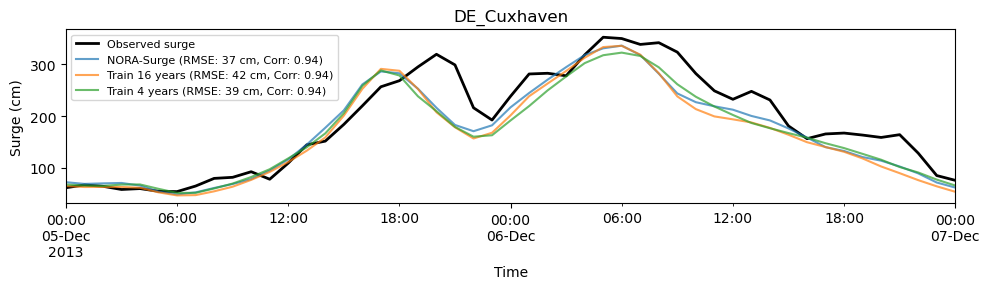

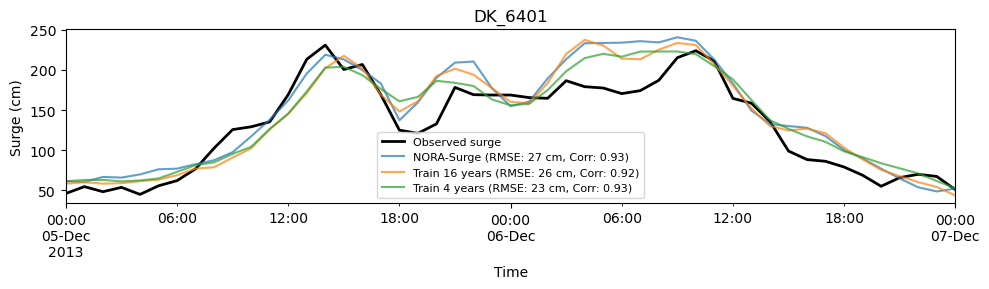

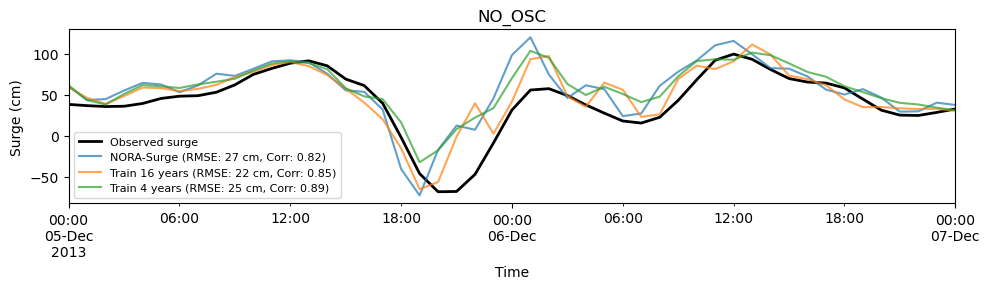

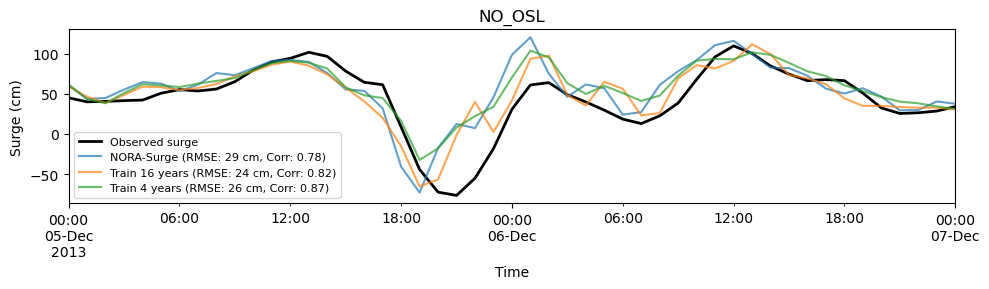

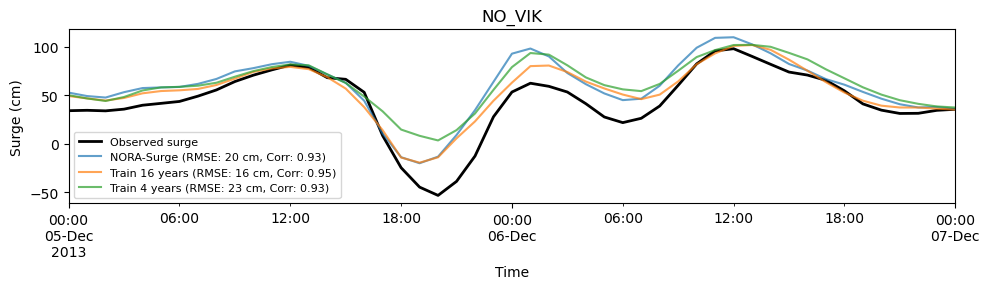

In [ ]:
for i in [7, 60, 77, 78, 85]:
    # Remove the mean before plotting
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'observation_surge'] -= np.mean(df_xaver.xs(i, level='station')['observation_surge'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'nora_surge'] -= np.mean(df_xaver.xs(i, level='station')['nora_surge'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'train16yr_uncorr_2010-2018_100k'] -= np.mean(df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'train4yr_uncorr_2010-2018_100k'] -= np.mean(df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'].dropna())
    #
    figsize=(10,3)
    ax = df_xaver.xs(i, level='station').plot(y=['observation_surge'], figsize=figsize, linewidth=2, color='black')
    df_xaver.xs(i, level='station').plot(y=['nora_surge','train16yr_uncorr_2010-2018_100k', 'train4yr_uncorr_2010-2018_100k'], figsize=figsize, alpha=0.7, ax=ax)
    plt.title(df_obs.xs(i, level='station').stationid.values[0])
    # Calulate the stats:
    rmse_16yr = np.sqrt(np.mean((df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_16yr = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                            df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'].dropna())[0,1]
    rmse_4yr = np.sqrt(np.mean((df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_4yr = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                           df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'].dropna())[0,1]
    rmse_nora = np.sqrt(np.mean((df_xaver.xs(i, level='station')['nora_surge'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_nora = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                           df_xaver.xs(i, level='station')['nora_surge'].dropna())[0,1]
    # plt.text(0.05, 0.9, f'NORA Surge RMSE: {rmse_nora:.2f} cm, Corr: {corr_nora:.2f}\n16yr Uncorr RMSE: {rmse_16yr:.2f} cm, Corr: {corr_16yr:.2f}\n4yr Uncorr RMSE: {rmse_4yr:.2f} cm, Corr: {corr_4yr:.2f}', transform=plt.gca().transAxes, 
    #          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    # Change the names in the legend to include RMSE and Correlation
    new_labels = []
    for label in plt.gca().get_legend().get_texts():
        # print(label.get_text())
        if label.get_text() == 'train16yr_uncorr_2010-2018_100k':
            new_labels.append(f'Train 16 years (RMSE: {rmse_16yr:.0f} cm, Corr: {corr_16yr:.2f})')
        elif label.get_text() == 'train4yr_uncorr_2010-2018_100k':
            new_labels.append(f'Train 4 years (RMSE: {rmse_4yr:.0f} cm, Corr: {corr_4yr:.2f})')
        elif label.get_text() == 'nora_surge':
            new_labels.append(f'NORA-Surge (RMSE: {rmse_nora:.0f} cm, Corr: {corr_nora:.2f})')
        elif label.get_text() == 'observation_surge':
            new_labels.append('Observed surge')
        else:
            new_labels.append(label.get_text())
    plt.gca().legend(new_labels, fontsize=8)
    # plt.legend(fontsize=8)
    plt.xlabel('Time')
    plt.ylabel('Surge (cm)')
    plt.tight_layout()
    plt.show()

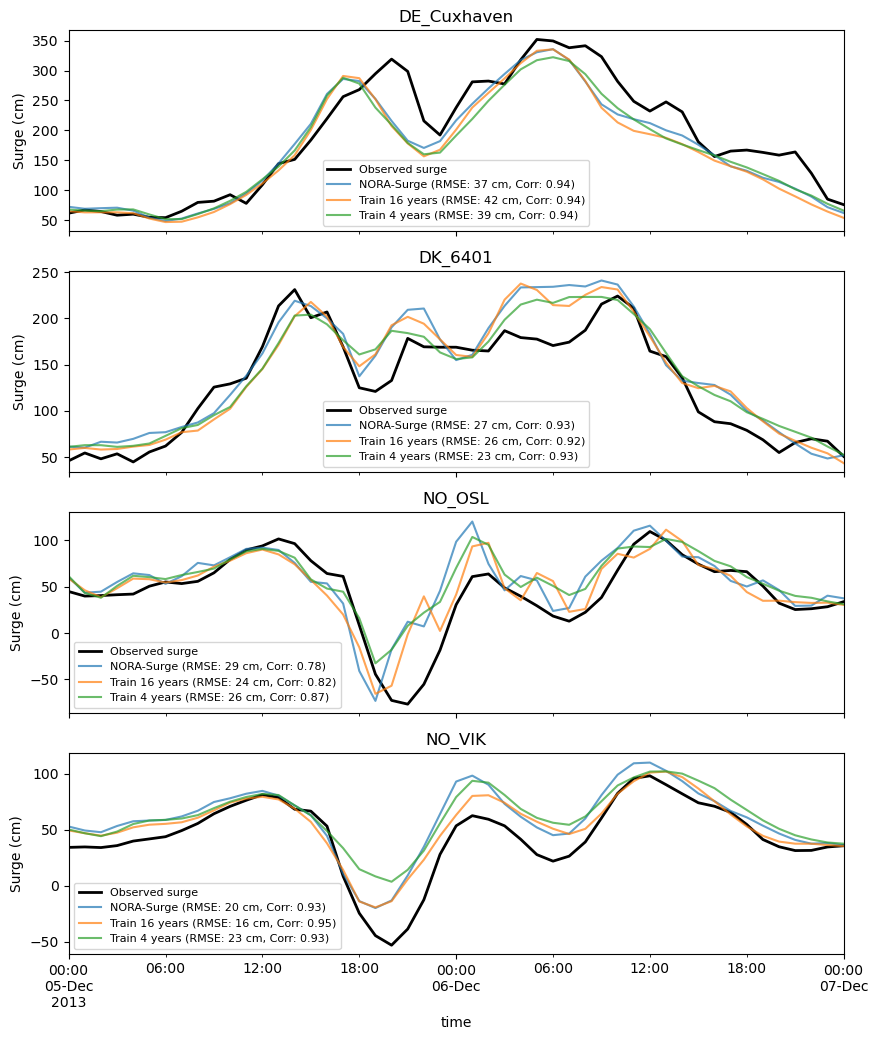

In [ ]:
# Do the same as above, but put all stations in one big figure with subplots for each station.
plot_stations = [7, 60, 78, 85]
fig, axes = plt.subplots(len(plot_stations), 1, figsize=(10, 3*len(plot_stations)), sharex=True)
for axi, i in enumerate(plot_stations):
    # Remove the mean before plotting
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'observation_surge'] -= np.mean(df_xaver.xs(i, level='station')['observation_surge'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'nora_surge'] -= np.mean(df_xaver.xs(i, level='station')['nora_surge'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'train16yr_uncorr_2010-2018_100k'] -= np.mean(df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'train4yr_uncorr_2010-2018_100k'] -= np.mean(df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'])
    # figsize=(10,3)
    ax = df_xaver.xs(i, level='station').plot(y=['observation_surge'], figsize=(10,3*len(plot_stations)), linewidth=2, color='black', ax=axes[axi])
    df_xaver.xs(i, level='station').plot(y=['nora_surge','train16yr_uncorr_2010-2018_100k', 'train4yr_uncorr_2010-2018_100k'], figsize=(10,3*len(plot_stations)), alpha=0.7, ax=ax)
    ax.set_title(df_obs.xs(i, level='station').stationid.values[0])
    # Calulate the stats:
    rmse_16yr = np.sqrt(np.mean((df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_16yr = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                            df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'].dropna())[0,1]
    rmse_4yr = np.sqrt(np.mean((df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_4yr = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                           df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'].dropna())[0,1]
    rmse_nora = np.sqrt(np.mean((df_xaver.xs(i, level='station')['nora_surge'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_nora = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                           df_xaver.xs(i, level='station')['nora_surge'].dropna())[0,1]
    # Change the names in the legend to include RMSE and Correlation
    # Get the label from axes[axi]
    new_labels = []
    for label in axes[axi].get_legend().get_texts():
        # print(label.get_text())
        if label.get_text() == 'train16yr_uncorr_2010-2018_100k':
            new_labels.append(f'Train 16 years (RMSE: {rmse_16yr:.0f} cm, Corr: {corr_16yr:.2f})')
        elif label.get_text() == 'train4yr_uncorr_2010-2018_100k':
            new_labels.append(f'Train 4 years (RMSE: {rmse_4yr:.0f} cm, Corr: {corr_4yr:.2f})')
        elif label.get_text() == 'nora_surge':
            new_labels.append(f'NORA-Surge (RMSE: {rmse_nora:.0f} cm, Corr: {corr_nora:.2f})')
        elif label.get_text() == 'observation_surge':
            new_labels.append('Observed surge')
        else:
            new_labels.append(label.get_text())
    axes[axi].legend(new_labels, fontsize=8)
    axes[axi].set_ylabel('Surge (cm)')

In [ ]:
# all_rmse, all_bias, all_corr
for keyes in df_xaver.columns:
    try:
        print(keyes, np.mean(stats_xaver[0][keyes]), np.mean(stats_xaver[2][keyes]))
    except:
        pass

nora_surge 15.991031 0.9072846520838309
nora_surge_corrected 15.080088781158263 0.9132518225421321
train16yr_uncorr_2010-2018_100k 16.07620167297561 0.9066447125526336
train4yr_uncorr_2010-2018_100k 15.846830603470277 0.9047991839787523


In [ ]:
df_obs

stationid   latitude  longitude  observation  \
station time                                                                   
0       2010-01-01 00:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
        2010-01-01 01:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
        2010-01-01 02:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
        2010-01-01 03:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
        2010-01-01 04:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
...                                   ...        ...        ...          ...   
97      2019-01-01 19:00:00       UK_Wick  58.440971  -3.086306   270.500000   
        2019-01-01 20:00:00       UK_Wick  58.440971  -3.086306   286.100006   
        2019-01-01 21:00:00       UK_Wick  58.440971  -3.086306   269.399994   
        2019-01-01 22:00:00       UK_Wick  58.440971  -3.086306   231.199997   
        2019-01-01 23:00:00       UK_Wick  58.440971  -3.086306   181.899994   

                             pytide_prediction  q_flag  nora_surge  \
station time                                                         
0       2010-01-01 00:00:00         127.228615     0.0  -40.153900   
        2010-01-01 01:00:00          64.462318     0.0  -38.648827   
        2010-01-01 02:00:00          -7.212074     0.0  -37.193420   
        2010-01-01 03:00:00         -66.939262     0.0  -35.668941   
        2010-01-01 04:00:00        -115.728935     0.0  -34.284744   
...                                        ...     ...         ...   
97      2019-01-01 19:00:00         303.047913     1.0  -14.649345   
        2019-01-01 20:00:00         315.238861     1.0  -15.854261   
        2019-01-01 21:00:00         300.459564     1.0  -19.501032   
        2019-01-01 22:00:00         264.531036     1.0  -23.495564   
        2019-01-01 23:00:00         217.547470     1.0  -26.658443   

                             observation_surge  nora_surge_corrected  \
station time                                                           
0       2010-01-01 00:00:00                NaN            -30.783630   
        2010-01-01 01:00:00                NaN            -29.278555   
        2010-01-01 02:00:00                NaN            -27.823151   
        2010-01-01 03:00:00                NaN            -26.298672   
        2010-01-01 04:00:00                NaN            -24.914473   
...                                        ...                   ...   
97      2019-01-01 19:00:00         -32.547913                   NaN   
        2019-01-01 20:00:00         -29.138855                   NaN   
        2019-01-01 21:00:00         -31.059570                   NaN   
        2019-01-01 22:00:00         -33.331039                   NaN   
        2019-01-01 23:00:00         -35.647476                   NaN   

                             train16yr_uncorr_10d_100k  ...  \
station time                                            ...   
0       2010-01-01 00:00:00                        NaN  ...   
        2010-01-01 01:00:00                        NaN  ...   
        2010-01-01 02:00:00                        NaN  ...   
        2010-01-01 03:00:00                        NaN  ...   
        2010-01-01 04:00:00                        NaN  ...   
...                                                ...  ...   
97      2019-01-01 19:00:00                        NaN  ...   
        2019-01-01 20:00:00                        NaN  ...   
        2019-01-01 21:00:00                        NaN  ...   
        2019-01-01 22:00:00                        NaN  ...   
        2019-01-01 23:00:00                        NaN  ...   

                             train5yr_uncorr_10d_100k  \
station time                                            
0       2010-01-01 00:00:00                       NaN   
        2010-01-01 01:00:00                       NaN   
        2010-01-01 02:00:00                       NaN   
        2010-01-01 03:00:00           

In [ ]:
# Create a heatmap scatterplot for all data points comparing observation_surge and train16yr_uncorr_2010-2018_100k
which_exp = 'train16yr_uncorr_2010-2018_100k'
# which_exp = 'train4yr_uncorr_2010-2018_100k'
# which_exp = 'nora_surge'
x = df_obs['observation_surge']
y = df_obs[which_exp]
# Remove NaN and inf values
mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
x = x[mask]
y = y[mask]
# Remove the mean from both x and y to focus on surge anomalies
x = x - np.mean(x)
y = y - np.mean(y)


In [ ]:
# # All stations
# minval = -400
# maxval = 400
# Norwegian stations only
minval = -100
maxval = 150

In [ ]:
# # Create heatmap scatterplot
# import seaborn as sns
# # Create a 2D histogram (heatmap scatterplot)
# plt.figure(figsize=(8,6))
# sns.kdeplot(x=x, y=y, fill=True, cmap='viridis', levels=100, thresh=0.05)
# plt.plot([minval, maxval], [minval, maxval], 'r--')
# plt.xlim([minval, maxval])
# plt.ylim([minval, maxval])
# plt.xlabel('Observed Surge (cm)')
# plt.ylabel(f'Modeled Surge ({which_exp}) (cm)')
# plt.title('Heatmap Scatterplot of Observed vs Modeled Surge')
# plt.grid(True)
# ofile_fig = os.path.join(odir_figs, f'heatmap_scatter_observed_vs_modeled_surge_{which_exp}.png')
# plt.savefig(ofile_fig)
# plt.show()
# plt.close()

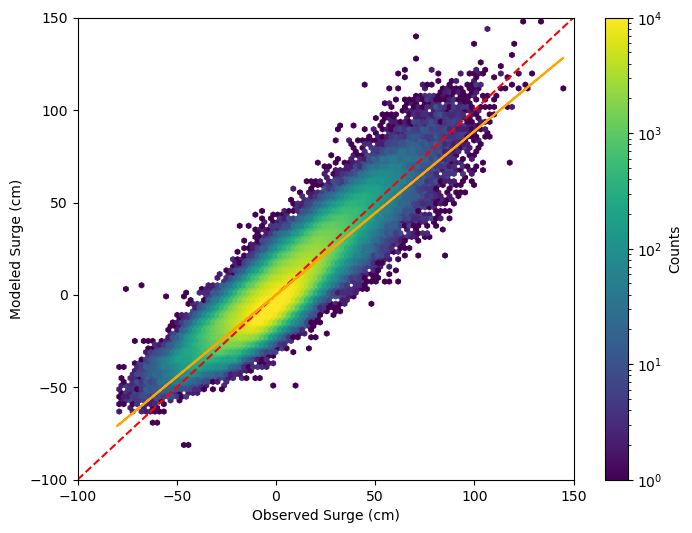

In [ ]:
# Do the same as above, but not using seaborn, just matplotlib with hexbin.
# Use log scale for colorbar.
plt.figure(figsize=(8,6))
plt.hexbin(x, y, gridsize=100, cmap='viridis', mincnt=1, bins='log', vmax=10000)
plt.plot([minval, maxval], [minval, maxval], 'r--')
# Also add a regression line based on x and y
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='orange', label='Regression line')
# plt.legend()
plt.xlim([minval, maxval])
plt.ylim([minval, maxval])
plt.xlabel('Observed Surge (cm)')
plt.ylabel(f'Modeled Surge (cm)')
# plt.ylabel(f'Modeled Surge ({which_exp}) (cm)')
# plt.title('Hexbin Scatterplot of Observed vs Modeled Surge')
plt.colorbar(label='Counts')
ofile_fig = os.path.join(odir_figs, f'hexbin_scatter_observed_vs_modeled_surge_{which_exp}.png')
plt.savefig(ofile_fig)
plt.show()
plt.close()

In [ ]:
# Plot the same as above (run plotting in above cell), but only for Norwegian stations.
df_obs_no = df_obs[df_obs.index.get_level_values('station').isin(no_station_sids)]
x = df_obs_no['observation_surge']
y = df_obs_no[which_exp]
# Remove NaN and inf values
mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
x = x[mask]
y = y[mask]
# Remove the mean from both x and y to focus on surge anomalies
x = x - np.mean(x)
y = y - np.mean(y)

--- Ellipse Properties (5 Standard Deviations) ---
Major Axis Length: 224.8655
Minor Axis Length: 59.0343
Angle of Rotation: 45.65 degrees


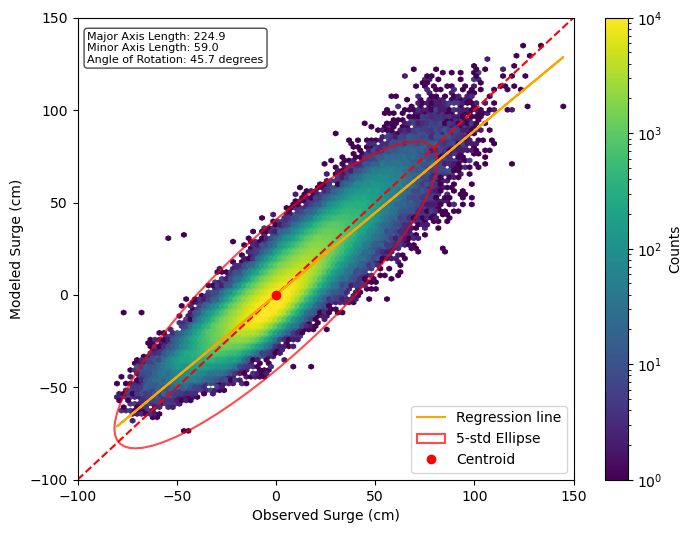

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def get_ellipse_parameters(x, y, n_std=2.0):
    """
    Calculates the parameters for an ellipse fitting the data distribution.
    
    Args:
        x, y: Array-like data points.
        n_std: Number of standard deviations for the ellipse radius 
               (2.0 corresponds to approx 95% confidence).
               
    Returns:
        width, height, angle (in degrees), mean_x, mean_y
    """
    # 1. Calculate the covariance matrix and the mean
    cov = np.cov(x, y)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    # 2. Calculate eigenvalues and eigenvectors of the covariance matrix
    # These represent the variance spread and direction
    eigenvals, eigenvecs = np.linalg.eigh(cov)

    # 3. Sort eigenvalues/vecs so that the largest is the major axis
    order = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[order]
    eigenvecs = eigenvecs[:, order]

    # 4. Calculate the angle of rotation
    # arctan2(y_component, x_component)
    vx, vy = eigenvecs[:, 0]
    theta = np.degrees(np.arctan2(vy, vx))

    # 5. Calculate width and height of the ellipse
    # Width and height are 2 * n_std * sqrt(eigenvalue)
    # We use sqrt because eigenvalues represent variance (sigma^2)
    width = 2 * n_std * np.sqrt(eigenvals[0])
    height = 2 * n_std * np.sqrt(eigenvals[1])

    return width, height, theta, mean_x, mean_y

# --- Main Execution ---

# # 1. Generate synthetic 2D data (Multivariate Normal Distribution)
# np.random.seed(42)
# mean = [10, 20]
# cov_matrix = [[20, 15], [15, 35]] # Correlated data
# data = np.random.multivariate_normal(mean, cov_matrix, size=5000)
# x, y = data[:, 0], data[:, 1]

# 2. Calculate Ellipse Parameters (using 2 standard deviations)
nstd = 5
width, height, angle, mx, my = get_ellipse_parameters(x, y, n_std=nstd)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Draw the Hexbin plot
hb = ax.hexbin(x, y, gridsize=100, cmap='viridis', mincnt=1, bins='log', vmax=10000)
ax.plot([minval, maxval], [minval, maxval], 'r--')
# Also add a regression line based on x and y
m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color='orange', label='Regression line')
# plt.legend()
ax.set_xlim([minval, maxval])
ax.set_ylim([minval, maxval])
ax.set_xlabel('Observed Surge (cm)')
ax.set_ylabel(f'Modeled Surge (cm)')

cb = fig.colorbar(hb, ax=ax, label='Counts')

# Draw the Ellipse
ellipse = Ellipse(xy=(mx, my), width=width, height=height, angle=angle, 
                  edgecolor='red', fc='None', lw=1.5, label=f'{nstd}-std Ellipse', alpha=0.7)
ax.add_patch(ellipse)

# Add centroid marker
ax.plot(mx, my, 'ro', label='Centroid')

# Formatting
# ax.set_title("Hexbin Plot with Fitted Confidence Ellipse")
# ax.set_xlabel("X Variable")
# ax.set_ylabel("Y Variable")
ax.legend(loc='lower right')


# 4. Print Major and Minor Axis lengths
print(f"--- Ellipse Properties ({nstd} Standard Deviations) ---")
print(f"Major Axis Length: {width:.4f}")
print(f"Minor Axis Length: {height:.4f}")
print(f"Angle of Rotation: {angle:.2f} degrees")

# Add the above text to the plot:
ax.text(0.02, 0.97, 
        f"Major Axis Length: {width:.1f}\n"
        f"Minor Axis Length: {height:.1f}\n"
        f"Angle of Rotation: {angle:.1f} degrees",
        transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white", alpha=0.7))

plt.show()

## Distribution plots

In [ ]:
import seaborn as sns

In [ ]:
selected_exps = ['nora_surge', 'train16yr_uncorr_2010-2018_100k', 'train4yr_uncorr_2010-2018_100k']
selected_exps_names = ['NORA-Surge', 'Flo (train 16 years)', 'Flo (train 4 years)']

In [ ]:
# Make a time slice of df_obs for the 2010-2018 period
df_obs_2010_2018 = df_obs.loc[(df_obs.index.get_level_values('time') >= '2010-01-01') & (df_obs.index.get_level_values('time') <= '2018-12-31')]

In [ ]:
# ---------------------------------------------------------
# CODE TO CREATE THE VIOLIN PLOT
# ---------------------------------------------------------

# 1. Restructure the data for Seaborn
# We need columns: "Experiment Name", "Type" (Prediction vs Observation), and "Value"
plot_data_list = []

for exp in selected_exps:
    # Append the Experiment (Model) values
    sub_df_exp = pd.DataFrame({
        'Experiment Name': exp,
        'Type': 'Prediction',
        'Value': df_obs_2010_2018[exp]#-np.nanmean(df_obs[exp])  # Centering the modeled values
    })
    
    # Append the Observation values
    # Note: If you specifically need to compare against 'observation_surge' 
    # instead of 'observation', change the column name below.
    sub_df_obs = pd.DataFrame({
        'Experiment Name': exp,
        'Type': 'Observation',
        'Value': df_obs_2010_2018['observation_surge']#-np.nanmean(df_obs['observation_surge'])  # Centering the observed values
    })
    
    plot_data_list.append(sub_df_exp)
    plot_data_list.append(sub_df_obs)

# Concatenate all parts into one long DataFrame
plot_df = pd.concat(plot_data_list, ignore_index=True)



In [ ]:
# 2. Create the Split Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(
    data=plot_df, 
    x='Experiment Name', 
    y='Value', 
    hue='Type', 
    split=True,           # This splits the violin
    inner='quartile',     # Shows quartiles inside the violin
    palette={'Prediction': 'skyblue', 'Observation': 'orange'}
)

plt.title('Comparison of Selected Experiments vs Observations')
plt.xlabel('Experiment')
plt.ylabel('Value')
plt.ylim(-150, 150)
plt.legend(title='Data Type')
plt.tight_layout()

# Save or show the plot
# plt.savefig('violin_comparison.png')
plt.show()

ValueError: Could not interpret value `Experiment Name` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

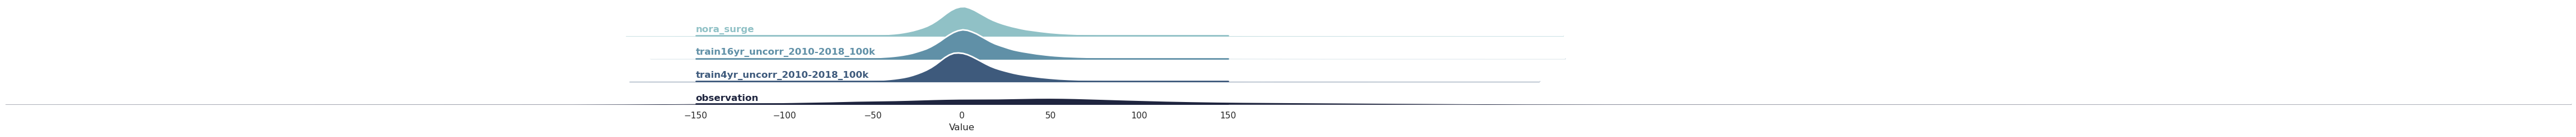

In [ ]:
# 1. Prepare the data
# We include 'observation' in the list to plot it alongside the experiments
cols_to_plot = selected_exps + ['observation']

# Convert to long format for Seaborn
plot_df = df_obs[cols_to_plot].melt(var_name='Source', value_name='Value')

# 2. Setup the Plot Theme
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the FacetGrid
# 'aspect' controls the width, 'height' controls the height of each ridge
pal = sns.cubehelix_palette(len(cols_to_plot), rot=-.25, light=.7)
g = sns.FacetGrid(plot_df, row="Source", hue="Source", aspect=15, height=.7, palette=pal)

# 3. Draw the densities
# Fill the area
g.map(sns.kdeplot, "Value", clip_on=False, fill=True, alpha=1, linewidth=1.5)
# Add a white outline for separation
g.map(sns.kdeplot, "Value", clip_on=False, color="w", lw=2)

# Add a horizontal line at y=0 for each plot
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# 4. Add Labels
def label(x, color, label):
    ax = plt.gca()
    # Position the label on the left
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, "Value")

# 5. Final Adjustments
# Overlap the plots to create the "ridge" effect
g.figure.subplots_adjust(hspace=-.25)

# Remove axes titles and ticks for a cleaner look
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

g.set_xlim(-150, 150)

plt.xlabel("Value")
plt.show()

In [ ]:
df_obs_2010_2018['observation_surge'][np.isfinite(df_obs_2010_2018['observation_surge'])]

station  time               
0        2014-01-19 07:00:00    -94.110168
         2014-01-19 08:00:00   -101.850327
         2014-01-19 09:00:00    -96.646225
         2014-01-19 10:00:00    -92.467705
         2014-01-19 11:00:00    -96.183144
                                   ...    
97       2018-12-30 20:00:00     -2.516388
         2018-12-30 21:00:00     -1.198502
         2018-12-30 22:00:00     -1.167480
         2018-12-30 23:00:00      0.945335
         2018-12-31 00:00:00     -0.577377
Name: observation_surge, Length: 6652035, dtype: float32

In [ ]:
cols_to_plot = selected_exps + ['observation_surge']
namelist = selected_exps_names + ['Observation']    


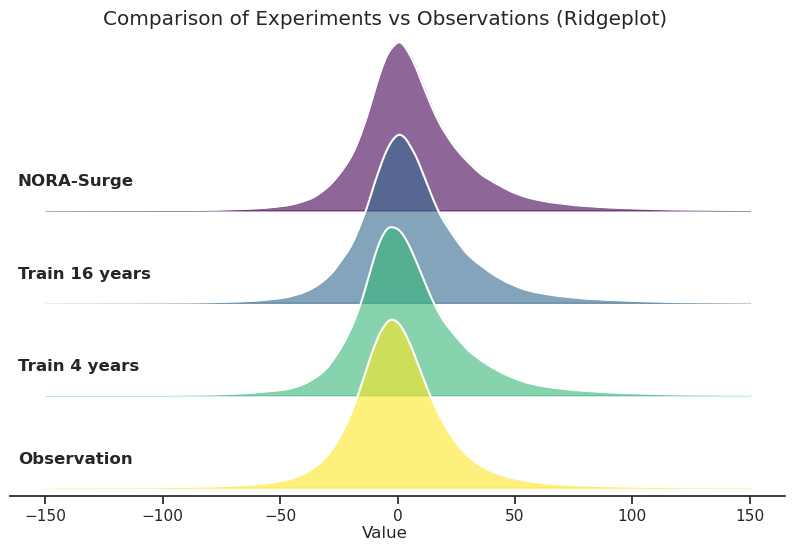

In [ ]:
from scipy.stats import gaussian_kde


# 1. Setup Figure and Axes
# Create a vertical stack of subplots sharing the X axis
fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=1, figsize=(10, 6), sharex=True)

# Generate a color palette
colors = plt.cm.viridis(np.linspace(0, 1, len(cols_to_plot)))

# Define the X grid for evaluating the KDE
# We extend the range slightly beyond the data min/max
x_min = -150
x_max = 150
x_grid = np.linspace(x_min, x_max, 500)

# 2. Iterate and Plot KDEs
for i, (col, ax) in enumerate(zip(cols_to_plot, axes)):
    # Calculate KDE
    data = df_obs_2010_2018[col][np.isfinite(df_obs_2010_2018[col])]
    kde = gaussian_kde(data)
    y = kde(x_grid)
    
    # Plot the filled density
    ax.fill_between(x_grid, 0, y, color=colors[i], alpha=0.6)
    # Plot the outline
    ax.plot(x_grid, y, color='white', lw=1.5)
    
    # Visual Styling to Create the "Ridge" Look
    ax.patch.set_alpha(0)  # Make axis background transparent
    
    # Remove spines (borders)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Handle the bottom spine
    if i != len(cols_to_plot) - 1:
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(bottom=False)
    else:
        ax.spines['bottom'].set_visible(True)
        ax.tick_params(bottom=True)
        
    # Remove Y ticks and labels
    ax.set_yticks([])
    
    # Add the Label inside the plot area
    # ax.text(0.01, 0.2, col, transform=ax.transAxes, fontweight='bold', ha='left', va='center')
    ax.text(0.01, 0.2, namelist[i], transform=ax.transAxes, fontweight='bold', ha='left', va='center')

# 3. Adjust Layout for Overlap
# hspace negative brings the plots closer together to overlap
plt.subplots_adjust(hspace=-0.5)

# Add a global x-label
fig.text(0.5, 0.04, 'Value', ha='center', fontsize=12)

# Remove the top spine of the figure if desired (optional)
plt.suptitle('Comparison of Experiments vs Observations (Ridgeplot)', y=0.92)

# Save or Show
# plt.savefig('ridgeplot_matplotlib.png')
plt.show()

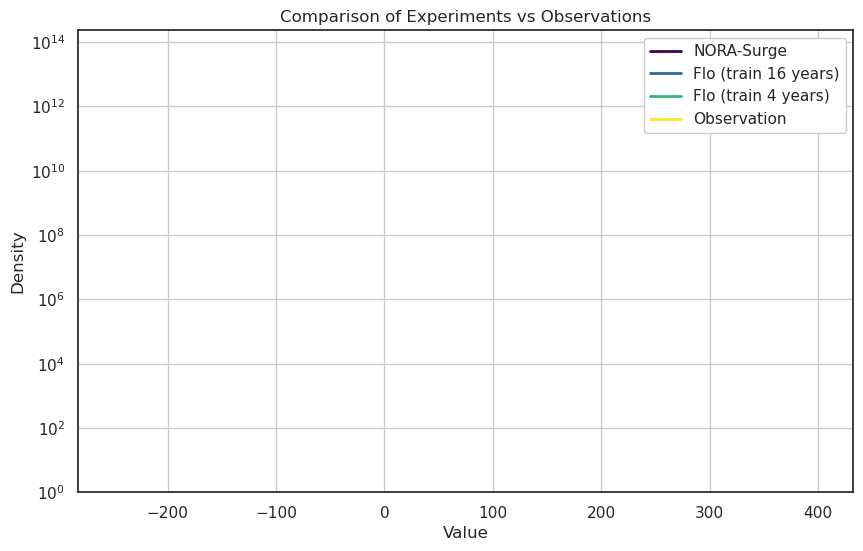

In [ ]:
# Using df_obs_2010_2018 from above, and cols_to_plot and namelist from above, plot a histogram of the diffent distributions (as lines) in one single plot.
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(cols_to_plot)))
for i, col in enumerate(cols_to_plot):
    data = df_obs_2010_2018[col][np.isfinite(df_obs_2010_2018[col])]
    kde = gaussian_kde(data)
    x_grid = np.linspace(-250, 400, 500)
    y = kde(x_grid)
    plt.plot(x_grid, y, color=colors[i], label=namelist[i], lw=2)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Comparison of Experiments vs Observations')
# Make sure legend has white background
plt.legend(loc='upper right', frameon=True, framealpha=1, facecolor='white')
# Logarithmic scale on y-axis
plt.yscale('log')
plt.ylim(1, None)
plt.grid()
plt.show()

In [ ]:
y

array([1.62849198e-07, 2.63109873e-07, 3.97179055e-07, 4.63334890e-07,
       4.78183153e-07, 2.83185012e-07, 1.79760898e-07, 2.80745930e-07,
       3.12325473e-07, 3.09421834e-07, 4.52531185e-07, 5.32603738e-07,
       4.50669559e-07, 4.82637716e-07, 4.41856201e-07, 3.56311794e-07,
       4.90717783e-07, 4.02139344e-07, 4.03225797e-07, 5.00793265e-07,
       3.98462973e-07, 3.19775624e-07, 3.84012358e-07, 6.57007425e-07,
       1.03292985e-06, 9.31603365e-07, 6.71890670e-07, 7.02539119e-07,
       6.75814381e-07, 7.96240278e-07, 1.06069005e-06, 1.12348551e-06,
       1.17752431e-06, 1.03912820e-06, 9.81990875e-07, 1.09990090e-06,
       1.34449189e-06, 1.35753818e-06, 1.26396794e-06, 1.28852212e-06,
       1.39722179e-06, 1.47743822e-06, 1.49744473e-06, 1.43644762e-06,
       1.30672275e-06, 1.50229204e-06, 1.90468361e-06, 1.94567325e-06,
       1.54709593e-06, 1.47495809e-06, 1.47576813e-06, 1.64341038e-06,
       2.16666522e-06, 2.13623273e-06, 2.04607453e-06, 1.94628745e-06,
      